# 0. Carga de librerias

In [1]:
import pandas as pd 
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import math
import warnings
warnings.filterwarnings("ignore")
from rdkit import Chem
from rdkit.Chem import Descriptors
from tqdm import tqdm
from mordred import Calculator, descriptors
from scipy.stats import pearsonr, spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split, StratifiedKFold,StratifiedGroupKFold,
                                     GridSearchCV)
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               ExtraTreesClassifier, AdaBoostClassifier)
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score,roc_curve, auc, f1_score,
                              matthews_corrcoef, confusion_matrix,
                              classification_report, precision_score,
                              recall_score, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance
OUTPUT_DIR_AD   = "resultados dominio de aplicabilidad mordred"
OUTPUT_DIR_ML   = "resultados modelos ML"
OUTPUT_DIR_INT = "resultados interpretabilidad Mordred"
FIGURAS = "figuras"

# 1. Carga del dataset

In [ ]:
df_final = pd.read_csv("Merge_ChEMBL_gallinamides.csv")

# 1.1 Calculo de los descriptores fisicoquimicos a partir de los SMILES etiquetados anteriormente

In [3]:
mols, valid_idx = [], []

print("Convirtiendo SMILES a objetos moleculares...")
for i, row in df_final.iterrows():
    mol = Chem.MolFromSmiles(row["smiles_std"])
    if mol is not None:
        mols.append(mol)
        valid_idx.append(i)
df_mol = df_final.iloc[valid_idx].reset_index(drop=True)
print(f"Moléculas válidas para Mordred: {len(mols)}")

calc = Calculator(descriptors, ignore_3D=True)
print("Calculando descriptores 2D (esto puede tardar varios minutos)...")
df_desc = calc.pandas(mols)
print(f"Descriptores calculados inicialmente: {df_desc.shape[1]}")

Convirtiendo SMILES a objetos moleculares...
Moléculas válidas para Mordred: 470
Calculando descriptores 2D (esto puede tardar varios minutos)...


 27%|██▋       | 126/470 [00:13<00:45,  7.57it/s]

c:\Users\angel\miniconda3\envs\tfm\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 28%|██▊       | 133/470 [00:14<01:00,  5.60it/s]

c:\Users\angel\miniconda3\envs\tfm\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\angel\miniconda3\envs\tfm\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\angel\miniconda3\envs\tfm\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\angel\miniconda3\envs\tfm\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


...

c:\Users\angel\miniconda3\envs\tfm\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 43%|████▎     | 202/470 [00:21<00:32,  8.12it/s]

c:\Users\angel\miniconda3\envs\tfm\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


100%|██████████| 470/470 [00:43<00:00, 10.86it/s]


Descriptores calculados inicialmente: 1613


# 1.2 Limpieza de descriptores

In [4]:
# Columnas vacias
df_desc = df_desc.dropna(axis=1, how="all")
# Columnas con >20% NaN
thresh = int(len(df_desc) * 0.8)
df_desc = df_desc.dropna(axis=1, thresh=thresh)
# Solo columnas numericas
df_desc = df_desc.select_dtypes(include=[np.number])
# Imputar NaN restantes con mediana
imputer_init = SimpleImputer(strategy="median")
X_arr = imputer_init.fit_transform(df_desc)
X_full = pd.DataFrame(X_arr, columns=df_desc.columns)
# Varianza cero
vt = VarianceThreshold(threshold=0.0)
X_full = pd.DataFrame(
    vt.fit_transform(X_full),
    columns=X_full.columns[vt.get_support()]
)
y = df_mol["Label_FP2"].values
print(f"Descriptores tras limpieza: {X_full.shape[1]}")

X_out = X_full.copy()
X_out.insert(0, "smiles_std", df_mol["smiles_std"].values)
X_out["Label_FP2"] = y
X_out.to_csv(f'{OUTPUT_DIR_ML}/df_descriptores.csv', index=False)
print(f"✅ paso4_descriptores_mordred.csv guardado.")

Descriptores tras limpieza: 1205
✅ paso4_descriptores_mordred.csv guardado.


# 1.3 Separación del dataset en conjuntos

In [5]:
def correlation_filter(X: pd.DataFrame, threshold: float,
                        method: str = "pearson") -> list:
    corr_matrix = X.corr(method=method).abs()
    upper= corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
                             )
    to_drop = {col for col in upper.columns if any(upper[col] >= threshold)}
    retained = [col for col in X.columns if col not in to_drop]
    return retained
    
feature_sets = {}   # {"nombre": [lista_columnas_retenidas]}

CORR_THRESHOLDS   = [0.7, 0.8, 0.9]

for thr in CORR_THRESHOLDS:
    for method in ["pearson", "spearman"]:
        key = f"{method}_thr{thr}"
        retained = correlation_filter(X_full, thr, method)
        feature_sets[key] = retained
        print(f"  {key:30s} → {len(retained):4d} descriptores retenidos")

feature_sets["no_filter"] = list(X_full.columns)
print(f"  {'no_filter':30s} → {len(X_full.columns):4d} descriptores (sin filtro)")

pd.DataFrame(
    {"feature_set": list(feature_sets.keys()),
     "n_features":  [len(v) for v in feature_sets.values()]}
).to_csv(f'{OUTPUT_DIR_ML}/paso5_feature_sets.csv', index=False)
print(f"✅ paso5_feature_sets.csv guardado.", sep=';')

  pearson_thr0.7                 →  149 descriptores retenidos
  spearman_thr0.7                →  154 descriptores retenidos
  pearson_thr0.8                 →  252 descriptores retenidos
  spearman_thr0.8                →  258 descriptores retenidos
  pearson_thr0.9                 →  443 descriptores retenidos
  spearman_thr0.9                →  389 descriptores retenidos
  no_filter                      → 1205 descriptores (sin filtro)
✅ paso5_feature_sets.csv guardado.


# 1.4 Desarrollo de los modelos e hiperparámetros

In [6]:
groups_all = X_full.round(6).apply(lambda r: hash(tuple(r)), axis=1)

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, test_idx = next(sgkf.split(X_full, y, groups=groups_all))

X_train_full = X_full.iloc[train_idx].reset_index(drop=True)
X_test_full  = X_full.iloc[test_idx].reset_index(drop=True)
y_train      = pd.Series(y).iloc[train_idx].reset_index(drop=True)
y_test       = pd.Series(y).iloc[test_idx].reset_index(drop=True)

print(f"Train: {len(y_train)} muestras | Test: {len(y_test)} muestras")
print(f"  Train activos: {y_train.sum()} ({y_train.mean():.1%})")
print(f"  Test  activos: {y_test.sum()} ({y_test.mean():.1%})")
 
# ── 6.2 Definición de modelos y rejillas de hiperparámetros ───────────────────
# Cada elemento: (nombre, estimador, param_grid)
# Los parámetros del pipeline se prefiján con 'clf__'
 
MODEL_DEFINITIONS = [
    # 1. Regresión Logística
    (
        "LogisticRegression",
        LogisticRegression(max_iter=1000, random_state=42),
        {
            "clf__C"      : [0.01, 0.1, 1, 10, 100],
            "clf__solver" : ["lbfgs", "liblinear"],
            "clf__penalty": ["l2"],
        }
    ),
    # 2. SVM con kernel RBF
    (
        "SVM_RBF",
        SVC(kernel="rbf", probability=True, random_state=42),
        {
            "clf__C"    : [0.1, 1, 10, 100],
            "clf__gamma": ["scale", "auto", 0.001, 0.01],
        }
    ),
    # 3. SVM lineal
    (
        "SVM_Linear",
        SVC(kernel="linear", probability=True, random_state=42),
        {"clf__C": [0.01, 0.1, 1, 10]}
    ),
    # 4. K-Nearest Neighbors
    (
        "KNeighbors",
        KNeighborsClassifier(),
        {
            "clf__n_neighbors": [3, 5, 7, 11, 15],
            "clf__weights"    : ["uniform", "distance"],
            "clf__metric"     : ["euclidean", "manhattan"],
        }
    ),
    # 5. Árbol de decisión
    (
        "DecisionTree",
        DecisionTreeClassifier(random_state=42),
        {
            "clf__max_depth"       : [3, 5, 7, 10, None],
            "clf__min_samples_split": [2, 5, 10],
            "clf__criterion"       : ["gini", "entropy"],
        }
    ),
    # 6. Random Forest
    (
        "RandomForest",
        RandomForestClassifier(random_state=42, n_jobs=-1),
        {
            "clf__n_estimators"    : [100, 200, 300],
            "clf__max_depth"       : [5, 10, 20, None],
            "clf__min_samples_split": [2, 5],
            "clf__max_features"    : ["sqrt", "log2"],
        }
    ),
    # 7. Extra Trees
    (
        "ExtraTrees",
        ExtraTreesClassifier(random_state=42, n_jobs=-1),
        {
            "clf__n_estimators"    : [100, 200, 300],
            "clf__max_depth"       : [5, 10, None],
            "clf__min_samples_split": [2, 5],
        }
    ),
    # 8. Gradient Boosting
    (
        "GradientBoosting",
        GradientBoostingClassifier(random_state=42),
        {
            "clf__n_estimators" : [100, 200],
            "clf__learning_rate": [0.05, 0.1, 0.2],
            "clf__max_depth"    : [3, 5, 7],
        }
    ),
    # 9. AdaBoost
    (
        "AdaBoost",
        AdaBoostClassifier(random_state=42, algorithm="SAMME"),
        {
            "clf__n_estimators" : [50, 100, 200],
            "clf__learning_rate": [0.5, 1.0, 2.0],
        }
    ),
    # 10. Red neuronal (MLP)
    (
        "MLP",
        MLPClassifier(max_iter=500, random_state=42),
        {
            "clf__hidden_layer_sizes": [(64,), (128,), (64, 32), (128, 64)],
            "clf__alpha"             : [1e-4, 1e-3, 1e-2],
            "clf__activation"        : ["relu", "tanh"],
        }
    ),
    # 11. Naive Bayes
    (
        "NaiveBayes",
        GaussianNB(),
        {"clf__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]}
    ),
    # 12. SGD Classifier
    (
        "SGD",
        SGDClassifier(loss="modified_huber", random_state=42,
                      max_iter=1000),
        {
            "clf__alpha"  : [1e-5, 1e-4, 1e-3, 1e-2],
            "clf__penalty": ["l2", "elasticnet"],
        }
    ),

    (
        "XGBoost",
        XGBClassifier(random_state=42, eval_metric="logloss",
                      use_label_encoder=False, n_jobs=-1),
        {
            "clf__n_estimators" : [100, 200, 300],
            "clf__max_depth"    : [3, 5, 7],
            "clf__learning_rate": [0.05, 0.1, 0.2],
            "clf__subsample"    : [0.8, 1.0],
        }
    ),

    (
        "LightGBM",
        LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
        {
            "clf__n_estimators" : [100, 200, 300],
            "clf__num_leaves"   : [31, 63, 127],
            "clf__learning_rate": [0.05, 0.1, 0.2],
        }
    )
]

Train: 377 muestras | Test: 93 muestras
  Train activos: 131 (34.7%)
  Test  activos: 36 (38.7%)


In [7]:
def evaluate(model, X_tr, X_te, y_tr, y_te):
    """Devuelve dict con métricas en train y test para análisis de overfitting."""
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)
 
    try:
        auc_tr = roc_auc_score(y_tr, model.predict_proba(X_tr)[:, 1])
        auc_te = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])
    except AttributeError:
        auc_tr = auc_te = np.nan
 
    return {
        "acc_train"     : accuracy_score(y_tr, y_pred_tr),
        "acc_test"      : accuracy_score(y_te, y_pred_te),
        "f1_train"      : f1_score(y_tr, y_pred_tr),
        "f1_test"       : f1_score(y_te, y_pred_te),
        "roc_auc_train" : auc_tr,
        "roc_auc_test"  : auc_te,
        "mcc_train"     : matthews_corrcoef(y_tr, y_pred_tr),
        "mcc_test"      : matthews_corrcoef(y_te, y_pred_te),
        "precision_test": precision_score(y_te, y_pred_te),
        "recall_test"   : recall_score(y_te, y_pred_te),
        "overfit_gap"   : accuracy_score(y_tr, y_pred_tr) - accuracy_score(y_te, y_pred_te),
    }

# 2. Desarrollo de los modelos de Machine Learning

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
all_results    = []
best_estimators = {}
 
n_total = len(MODEL_DEFINITIONS) * len(feature_sets)
print(f"\nEntrenando {len(MODEL_DEFINITIONS)} modelos × "
      f"{len(feature_sets)} feature sets = {n_total} experimentos...\n")
 
for fs_name, feat_cols in feature_sets.items():
    # Se entrenan los 7 feature sets (pearson/spearman x thr 0.7/0.8/0.9, + no_filter)
    # para poder comparar todos y escoger el mejor modelo global.
    X_tr = X_train_full[feat_cols]
    X_te = X_test_full[feat_cols]
 
    for model_name, estimator, param_grid in MODEL_DEFINITIONS:
        key = f"{model_name}__{fs_name}"
        print(f"  ▶ {key}")
 
        # Pipeline: imputación → escalado → clasificador
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler",  StandardScaler()),
            ("clf",     estimator),
        ])
 
        gs = GridSearchCV(
            pipe, param_grid,
            cv=cv,
            scoring="roc_auc",
            n_jobs=2,
            refit=True,
            return_train_score=True,
        )
        gs.fit(X_tr, y_train)
        best_estimators[key] = gs.best_estimator_
 
        metrics = evaluate(gs.best_estimator_, X_tr, X_te, y_train, y_test)
        metrics["model"]           = model_name
        metrics["feature_set"]     = fs_name
        metrics["n_features"]      = len(feat_cols)
        metrics["best_params"]     = str(gs.best_params_)
        metrics["cv_roc_auc_mean"] = gs.best_score_
        metrics["cv_roc_auc_std"]  = gs.cv_results_["std_test_score"][gs.best_index_]
 
        all_results.append(metrics)
        print(f"      CV AUC={gs.best_score_:.3f} | "
              f"Test AUC={metrics['roc_auc_test']:.3f} | "
              f"Gap={metrics['overfit_gap']:.3f}")
 
 
df_results = pd.DataFrame(all_results).sort_values("roc_auc_test", ascending=False)
df_results.to_csv(f'{OUTPUT_DIR_ML}/paso6_resultados_todos.csv',sep=";",  index=False)
print(f"\n✅ paso6_resultados_todos.csv guardado.")


Entrenando 14 modelos × 7 feature sets = 98 experimentos...

  ▶ LogisticRegression__pearson_thr0.7
      CV AUC=0.793 | Test AUC=0.851 | Gap=0.131
  ▶ SVM_RBF__pearson_thr0.7
      CV AUC=0.798 | Test AUC=0.855 | Gap=0.109
  ▶ SVM_Linear__pearson_thr0.7
      CV AUC=0.778 | Test AUC=0.833 | Gap=0.114
  ▶ KNeighbors__pearson_thr0.7
      CV AUC=0.824 | Test AUC=0.814 | Gap=0.101
  ▶ DecisionTree__pearson_thr0.7
      CV AUC=0.753 | Test AUC=0.669 | Gap=0.087
  ▶ RandomForest__pearson_thr0.7
      CV AUC=0.820 | Test AUC=0.891 | Gap=0.178
  ▶ ExtraTrees__pearson_thr0.7
      CV AUC=0.831 | Test AUC=0.884 | Gap=0.115
  ▶ GradientBoosting__pearson_thr0.7
      CV AUC=0.803 | Test AUC=0.924 | Gap=0.145
  ▶ AdaBoost__pearson_thr0.7
      CV AUC=0.797 | Test AUC=0.854 | Gap=0.133
  ▶ MLP__pearson_thr0.7
      CV AUC=0.809 | Test AUC=0.899 | Gap=0.156
  ▶ NaiveBayes__pearson_thr0.7
      CV AUC=0.698 | Test AUC=0.721 | Gap=-0.082
  ▶ SGD__pearson_thr0.7
      CV AUC=0.768 | Test AUC=0.808 | 

# 3. Evaluacion y seleccion del modelo 

In [9]:
df_results["score_balanced"] = (
    df_results["roc_auc_test"] - 0.5 * df_results["overfit_gap"].abs()
)
df_results = df_results.sort_values("score_balanced", ascending=False)
df_results.to_csv(f'{OUTPUT_DIR_ML}/paso7_resultados_rankeados.csv', sep=";", index=False)

# =============================================================================
# Paso 1: elegir el mejor feature set (threshold)
# =============================================================================
# Para cada feature set (pearson/spearman thr 0.7/0.8/0.9, no_filter) se toma
# el mejor score_balanced alcanzado por CUALQUIERA de los 14 modelos
# entrenados sobre el. Esto responde a "para que threshold los modelos
# funcionan mejor en conjunto", no solo que modelo individual es el mejor.
fs_ranking = (
    df_results.groupby("feature_set")["score_balanced"]
    .max()
    .sort_values(ascending=False)
)
print("\nRanking de feature sets (mejor score_balanced alcanzado en cada uno):")
print(fs_ranking.to_string())

best_fs_name = fs_ranking.index[0]
print(f"\nFeature set / threshold elegido: {best_fs_name}")

# =============================================================================
# Paso 2: dentro del feature set ganador, top 3 modelos
# =============================================================================
df_best_fs = (
    df_results[df_results["feature_set"] == best_fs_name]
    .sort_values("score_balanced", ascending=False)
    .reset_index(drop=True)
)
top3 = df_best_fs.head(3)

best_row = top3.iloc[0]
best_key = f"{best_row['model']}__{best_row['feature_set']}"

cols_show = ["model", "feature_set", "n_features", "roc_auc_test", "score_balanced"]
print(f"\nTOP 3 MODELOS DENTRO DE '{best_fs_name}':")
print(top3[cols_show].to_string(index=False))



Ranking de feature sets (mejor score_balanced alcanzado en cada uno):
feature_set
pearson_thr0.7     0.851289
pearson_thr0.9     0.839625
pearson_thr0.8     0.839121
no_filter          0.836669
spearman_thr0.7    0.827410
spearman_thr0.8    0.825948
spearman_thr0.9    0.825461

Feature set / threshold elegido: pearson_thr0.7

TOP 3 MODELOS DENTRO DE 'pearson_thr0.7':
           model    feature_set  n_features  roc_auc_test  score_balanced
GradientBoosting pearson_thr0.7         149      0.923977        0.851289
        LightGBM pearson_thr0.7         149      0.909357        0.847422
         XGBoost pearson_thr0.7         149      0.894250        0.826938



## 3.1 Rendimiento por modelo en funcion del threshold (Pearson y Spearman por separado)

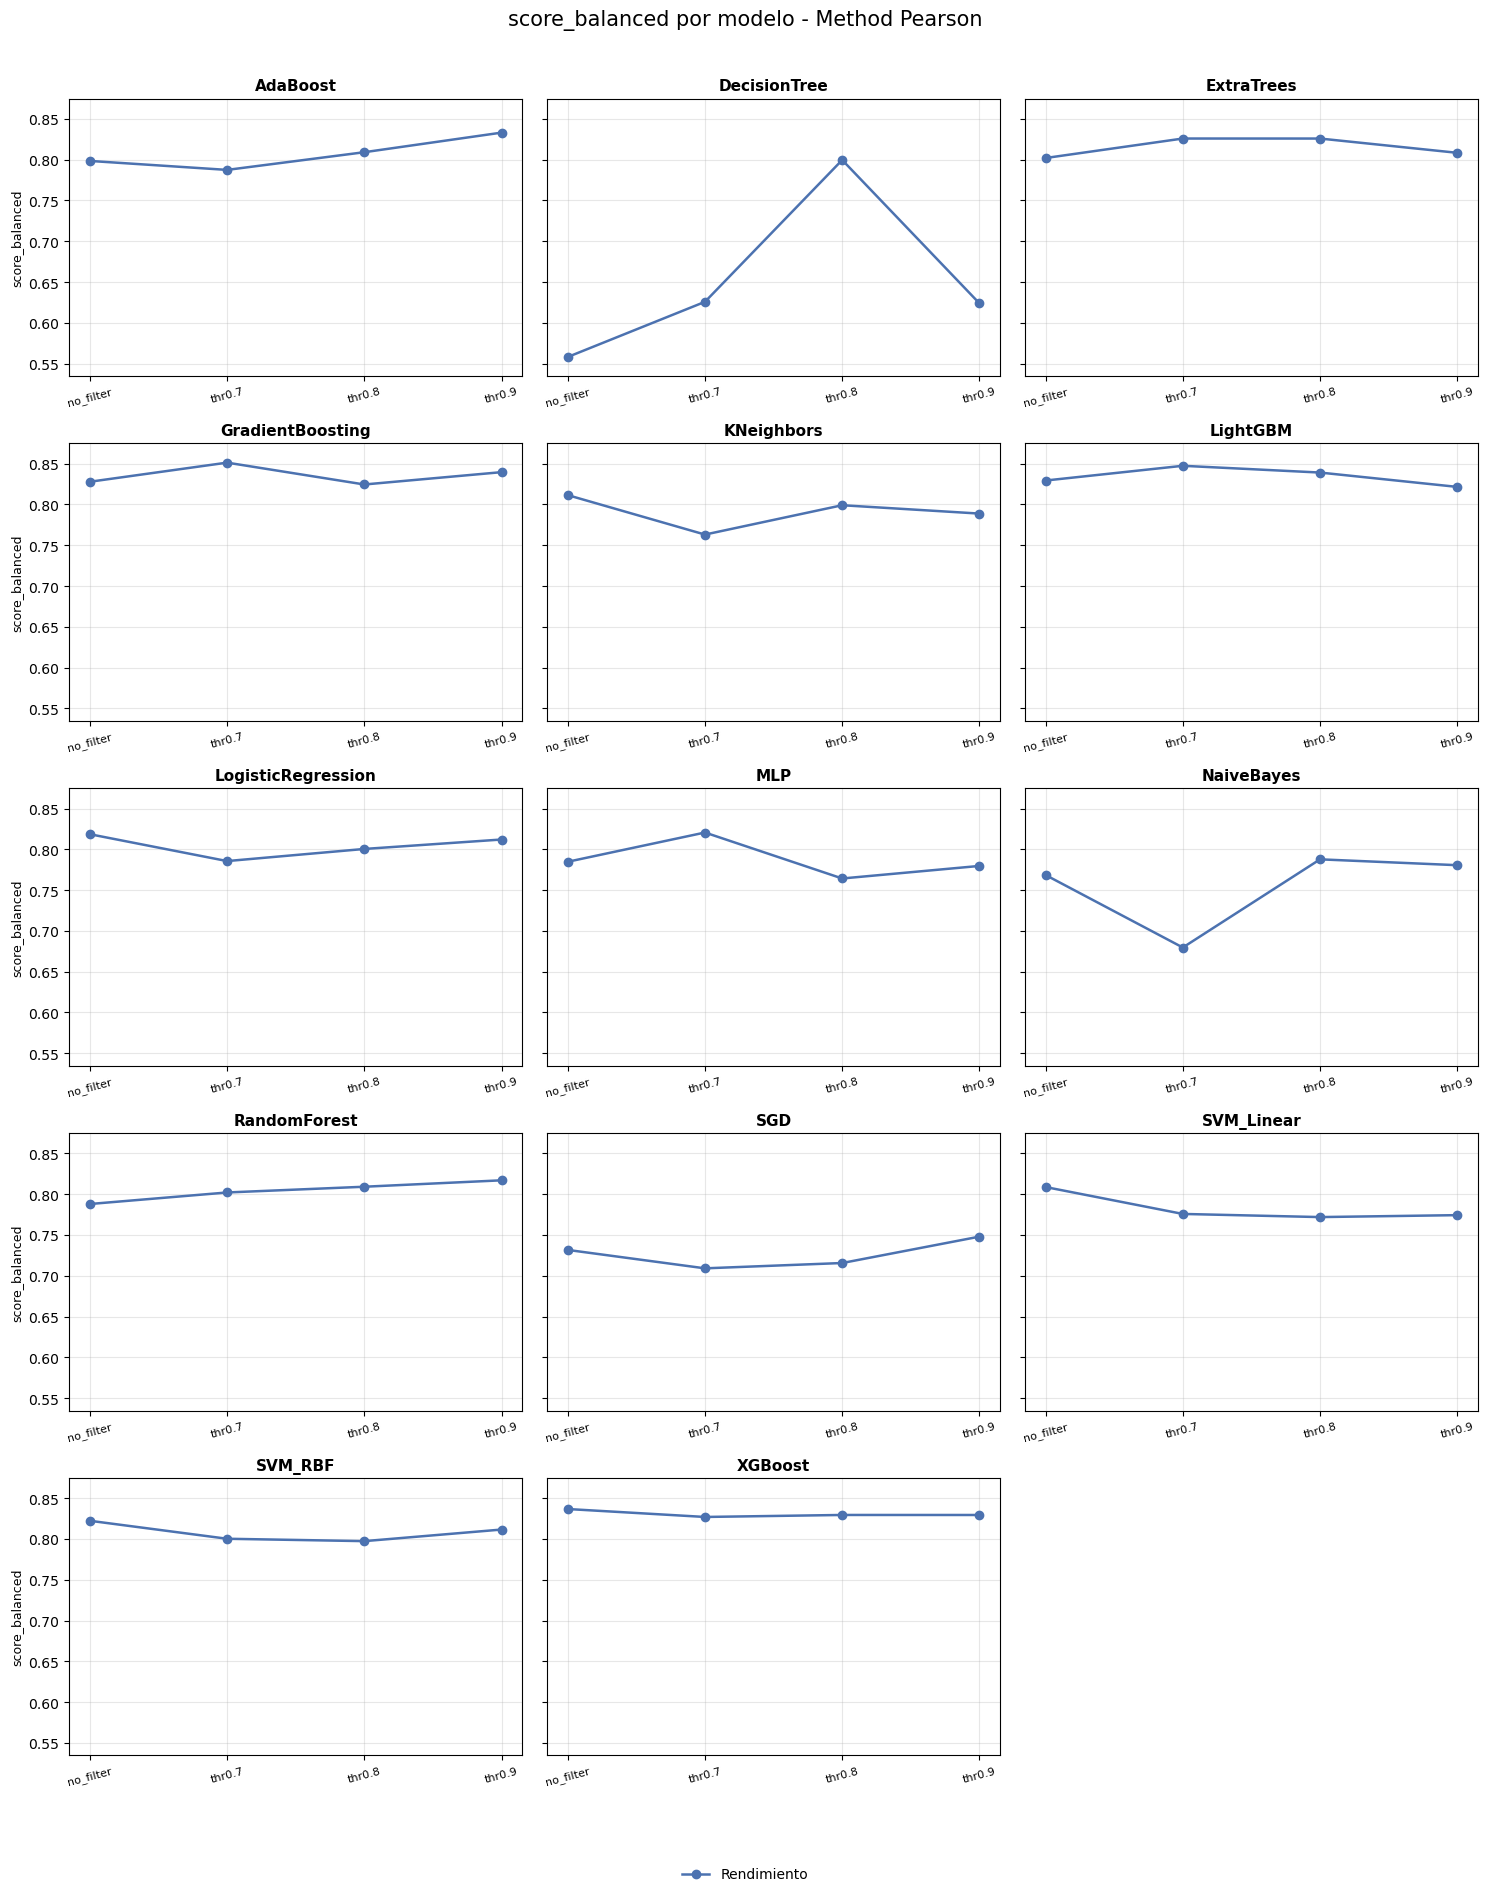

figuras/paso7b_rendimiento_vs_threshold_pearson_mordred.png guardado.


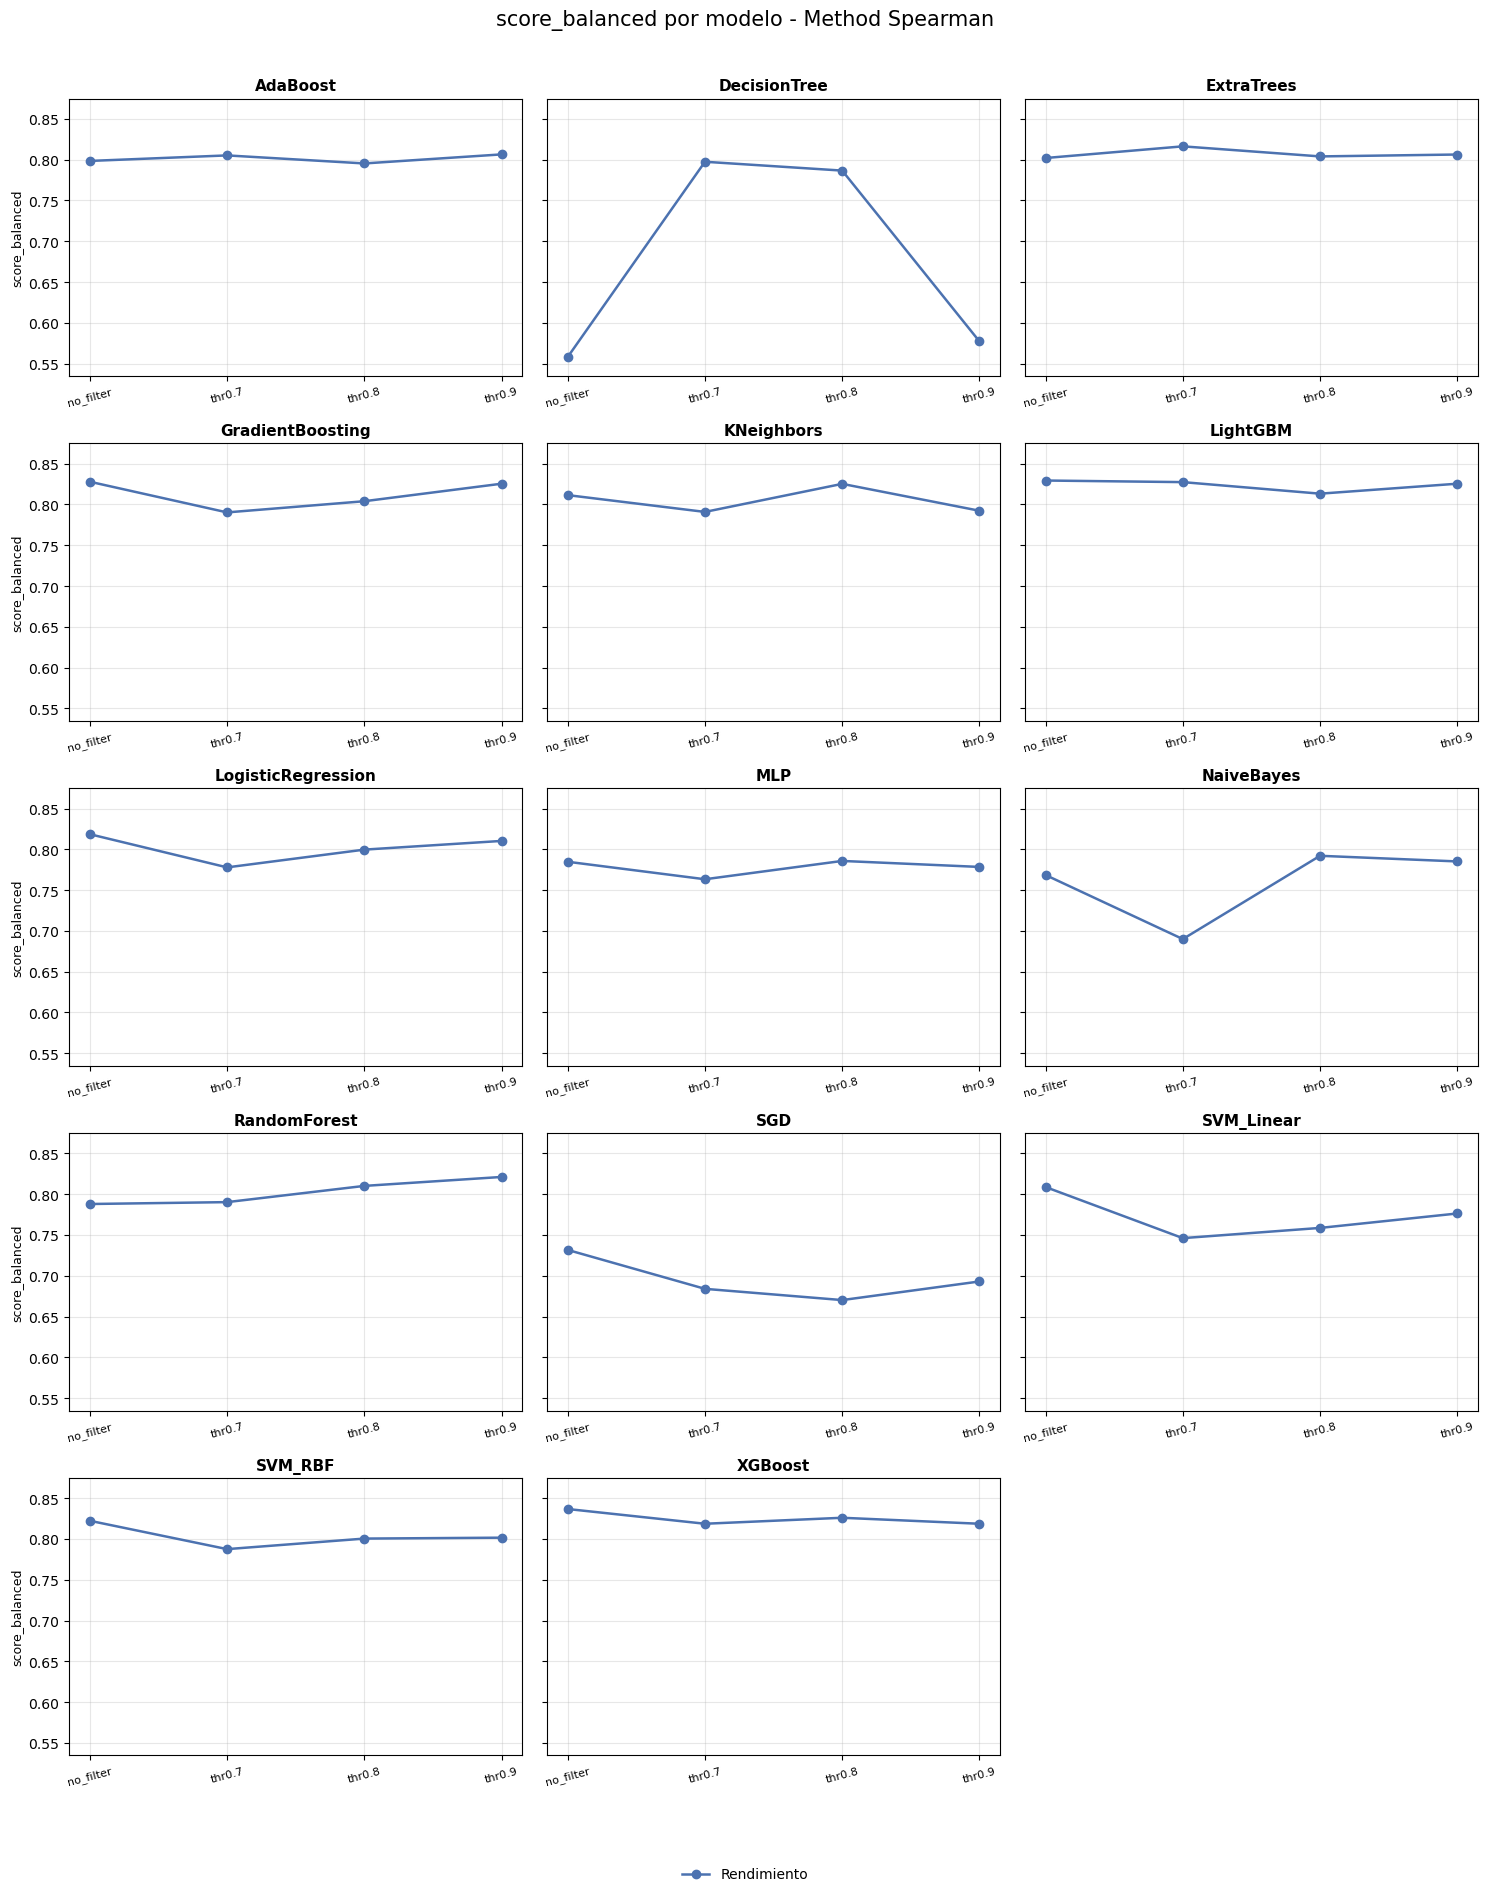

figuras/paso7b_rendimiento_vs_threshold_spearman_mordred.png guardado.


In [ ]:
METRIC_TO_PLOT = "score_balanced"   # alternativas: "roc_auc_test", "cv_roc_auc_mean", "mcc_test", "f1_test"

fs_x_order   = ["no_filter", "thr0.7", "thr0.8", "thr0.9"]
pearson_map  = {"no_filter": "no_filter", "thr0.7": "pearson_thr0.7",
                "thr0.8": "pearson_thr0.8", "thr0.9": "pearson_thr0.9"}
spearman_map = {"no_filter": "no_filter", "thr0.7": "spearman_thr0.7",
                 "thr0.8": "spearman_thr0.8", "thr0.9": "spearman_thr0.9"}
models_sorted = sorted(df_results["model"].unique())

# ── Rango global del eje Y (comun a TODOS los subplots de ambas figuras) ────
all_fs_names = list(pearson_map.values()) + list(spearman_map.values())
metric_vals_global = df_results.loc[df_results["feature_set"].isin(all_fs_names), METRIC_TO_PLOT]
y_min, y_max = metric_vals_global.min(), metric_vals_global.max()
y_pad = (y_max - y_min) * 0.08 if y_max > y_min else 0.05
Y_LIM = (y_min - y_pad, y_max + y_pad)
def plot_lineplot_by_method(method_name, fmap):
    cols = 3
    rows = math.ceil(len(models_sorted) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 3.5 + 0.8), sharex=False, sharey=True)
    axes = np.array(axes).reshape(-1)
    for i, model_name in enumerate(models_sorted):
        ax = axes[i]
        sub = df_results[df_results["model"] == model_name]
        y_vals = []
        for x_label in fs_x_order:
            fs_real = fmap[x_label]
            val = sub.loc[sub["feature_set"] == fs_real, METRIC_TO_PLOT]
            y_vals.append(val.values[0] if len(val) > 0 else np.nan)
        ax.plot(fs_x_order, y_vals, marker="o", color="#4C72B0",
                linewidth=1.8, markersize=6, label="Rendimiento")
        ax.set_title(model_name, fontsize=11, fontweight="bold")
        ax.set_ylim(Y_LIM)
        ax.grid(alpha=0.3)
        ax.tick_params(axis="x", rotation=15, labelsize=8)
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")
    for r in range(rows):
        axes[r * cols].set_ylabel(METRIC_TO_PLOT, fontsize=9)
    # ── Leyenda unica, debajo de toda la figura ──────────────────────────────
    legend_handles = [
        plt.Line2D([0], [0], color="#4C72B0", marker="o", linewidth=1.8, label="Rendimiento"),
    ]
    fig.legend(handles=legend_handles, loc="lower center", ncol=2,
               fontsize=10, bbox_to_anchor=(0.5, -0.02), frameon=False)
    plt.suptitle(f"{METRIC_TO_PLOT} por modelo - Method {method_name}", fontsize=15, y=1.01)
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    out_lineplot = f'{FIGURAS}/paso7b_rendimiento_vs_threshold_{method_name.lower()}_mordred.png'
    plt.savefig(out_lineplot, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"{out_lineplot} guardado.")
plot_lineplot_by_method("Pearson", pearson_map)
plot_lineplot_by_method("Spearman", spearman_map)

## 3.2 Realización de las matrices de confusión

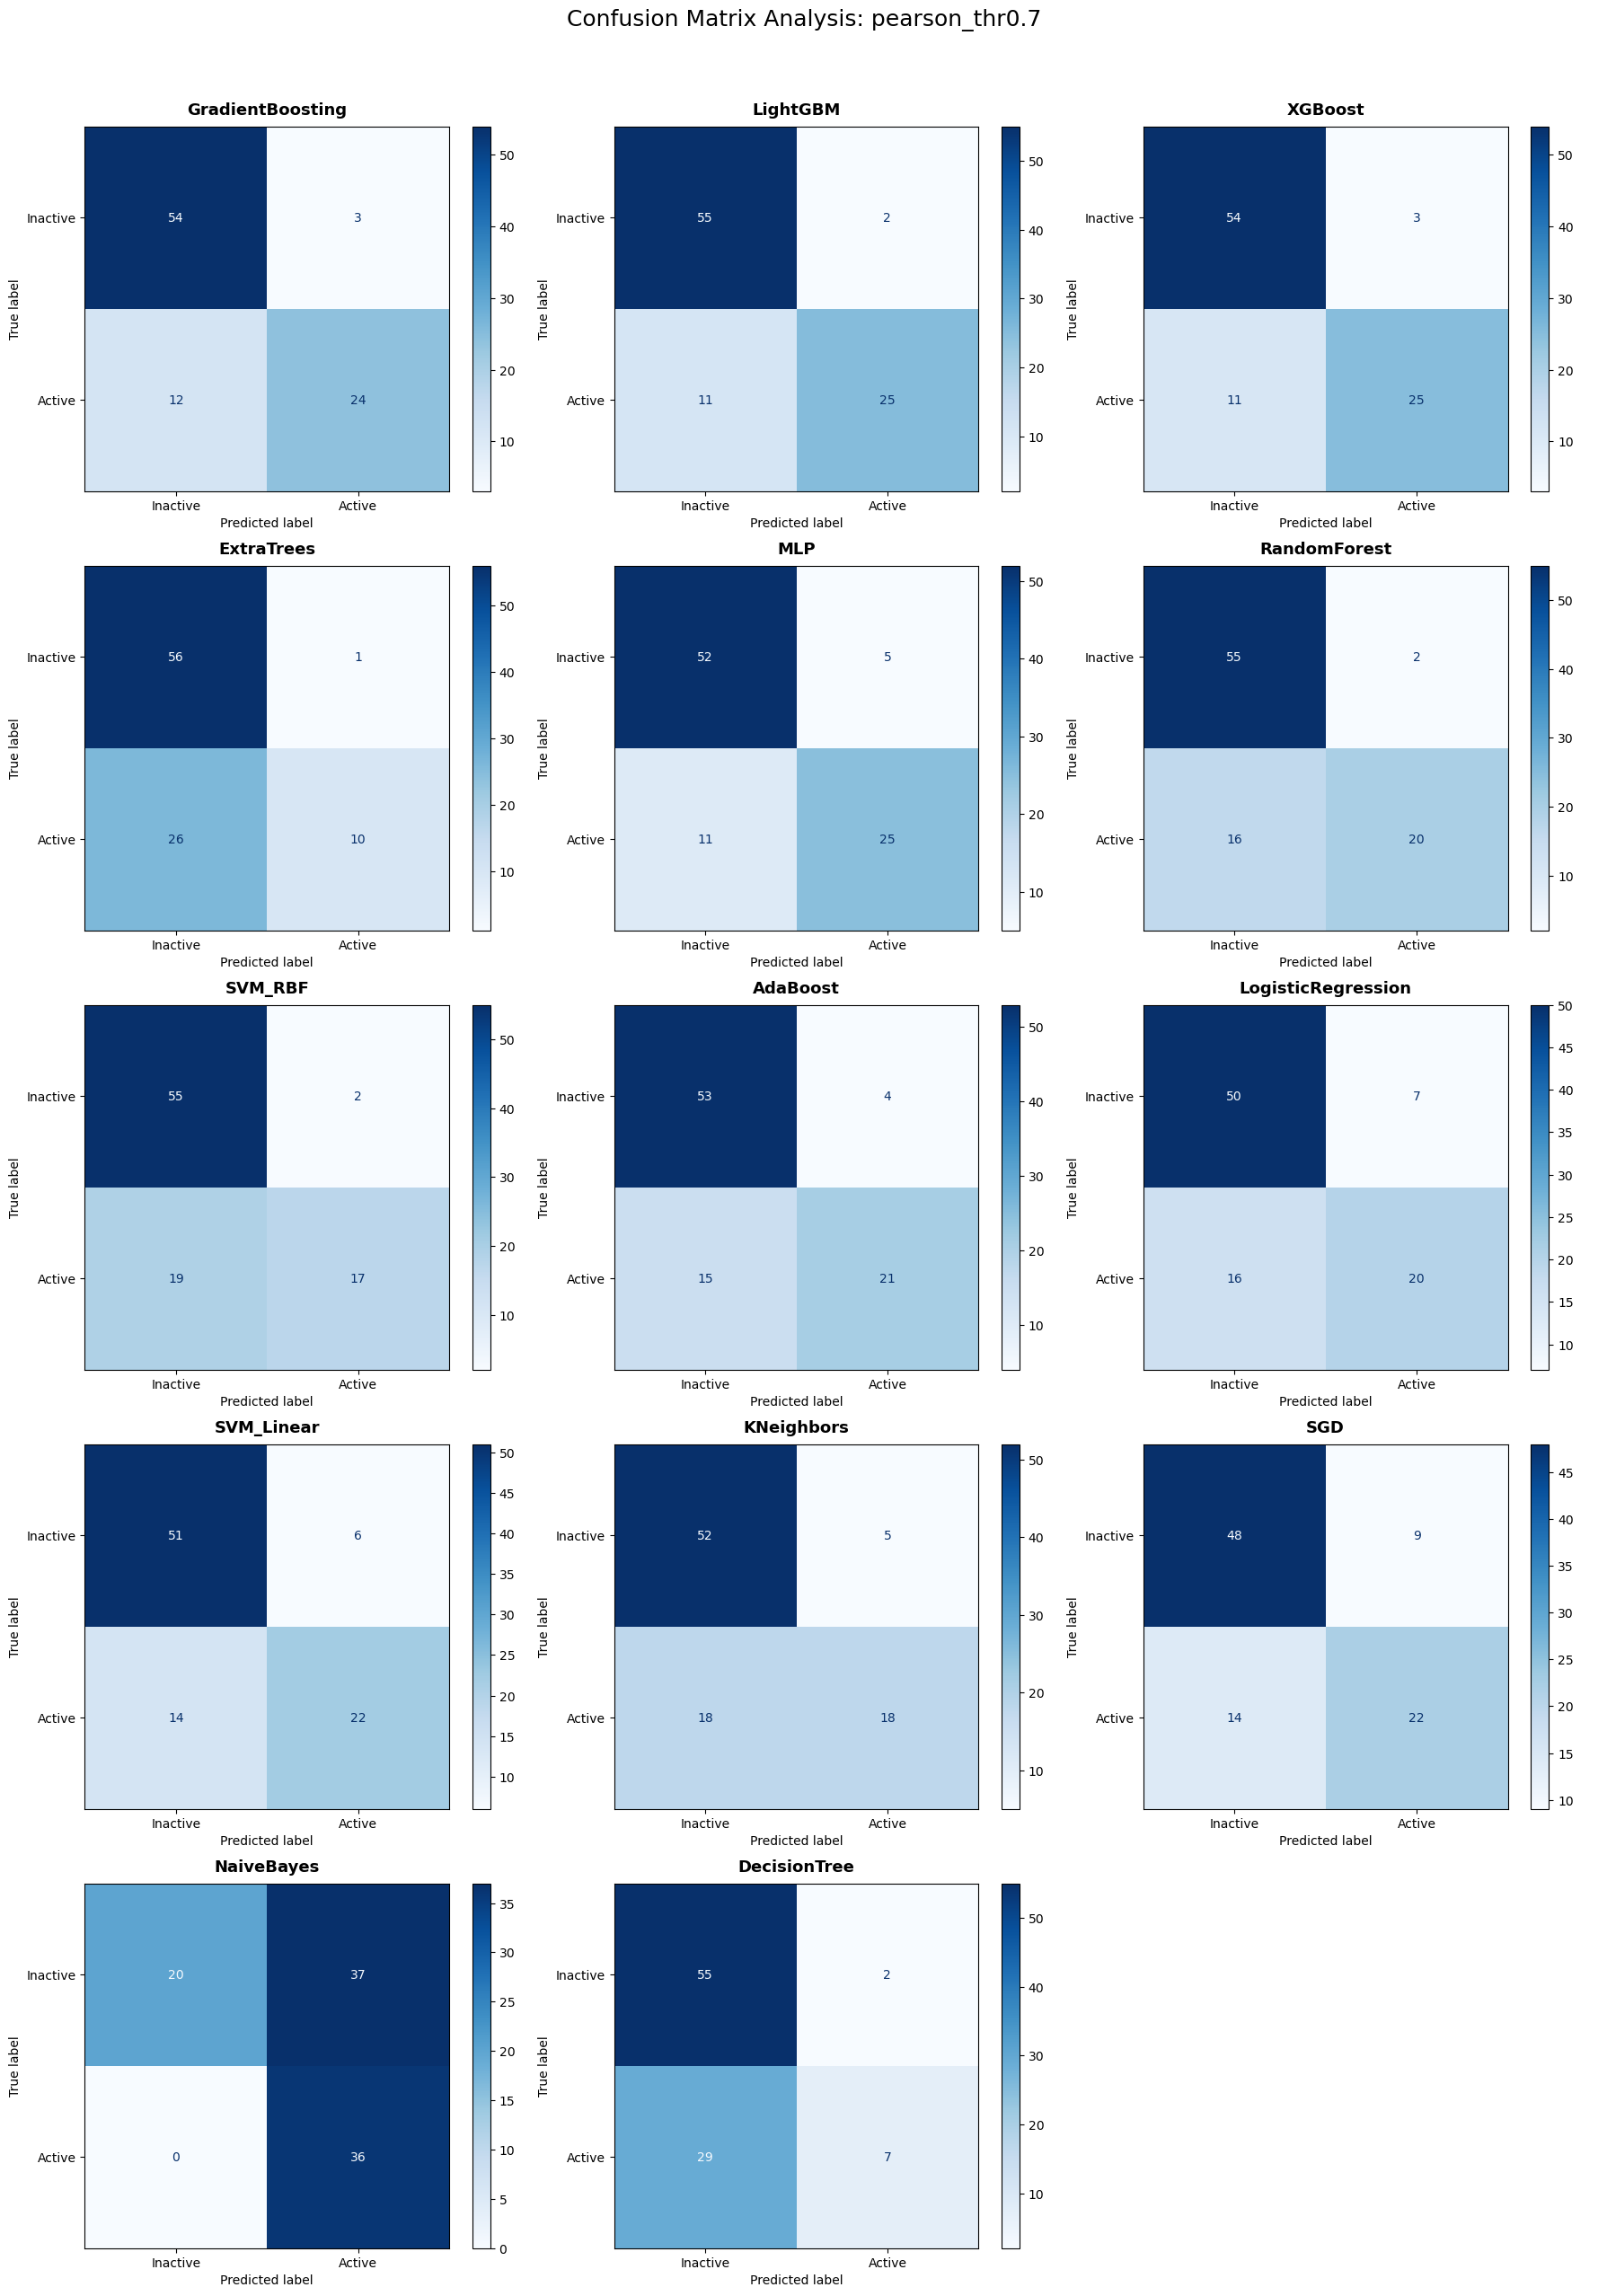

figuras/paso7_confusion_pearson_thr0.7_mordred.png guardado.


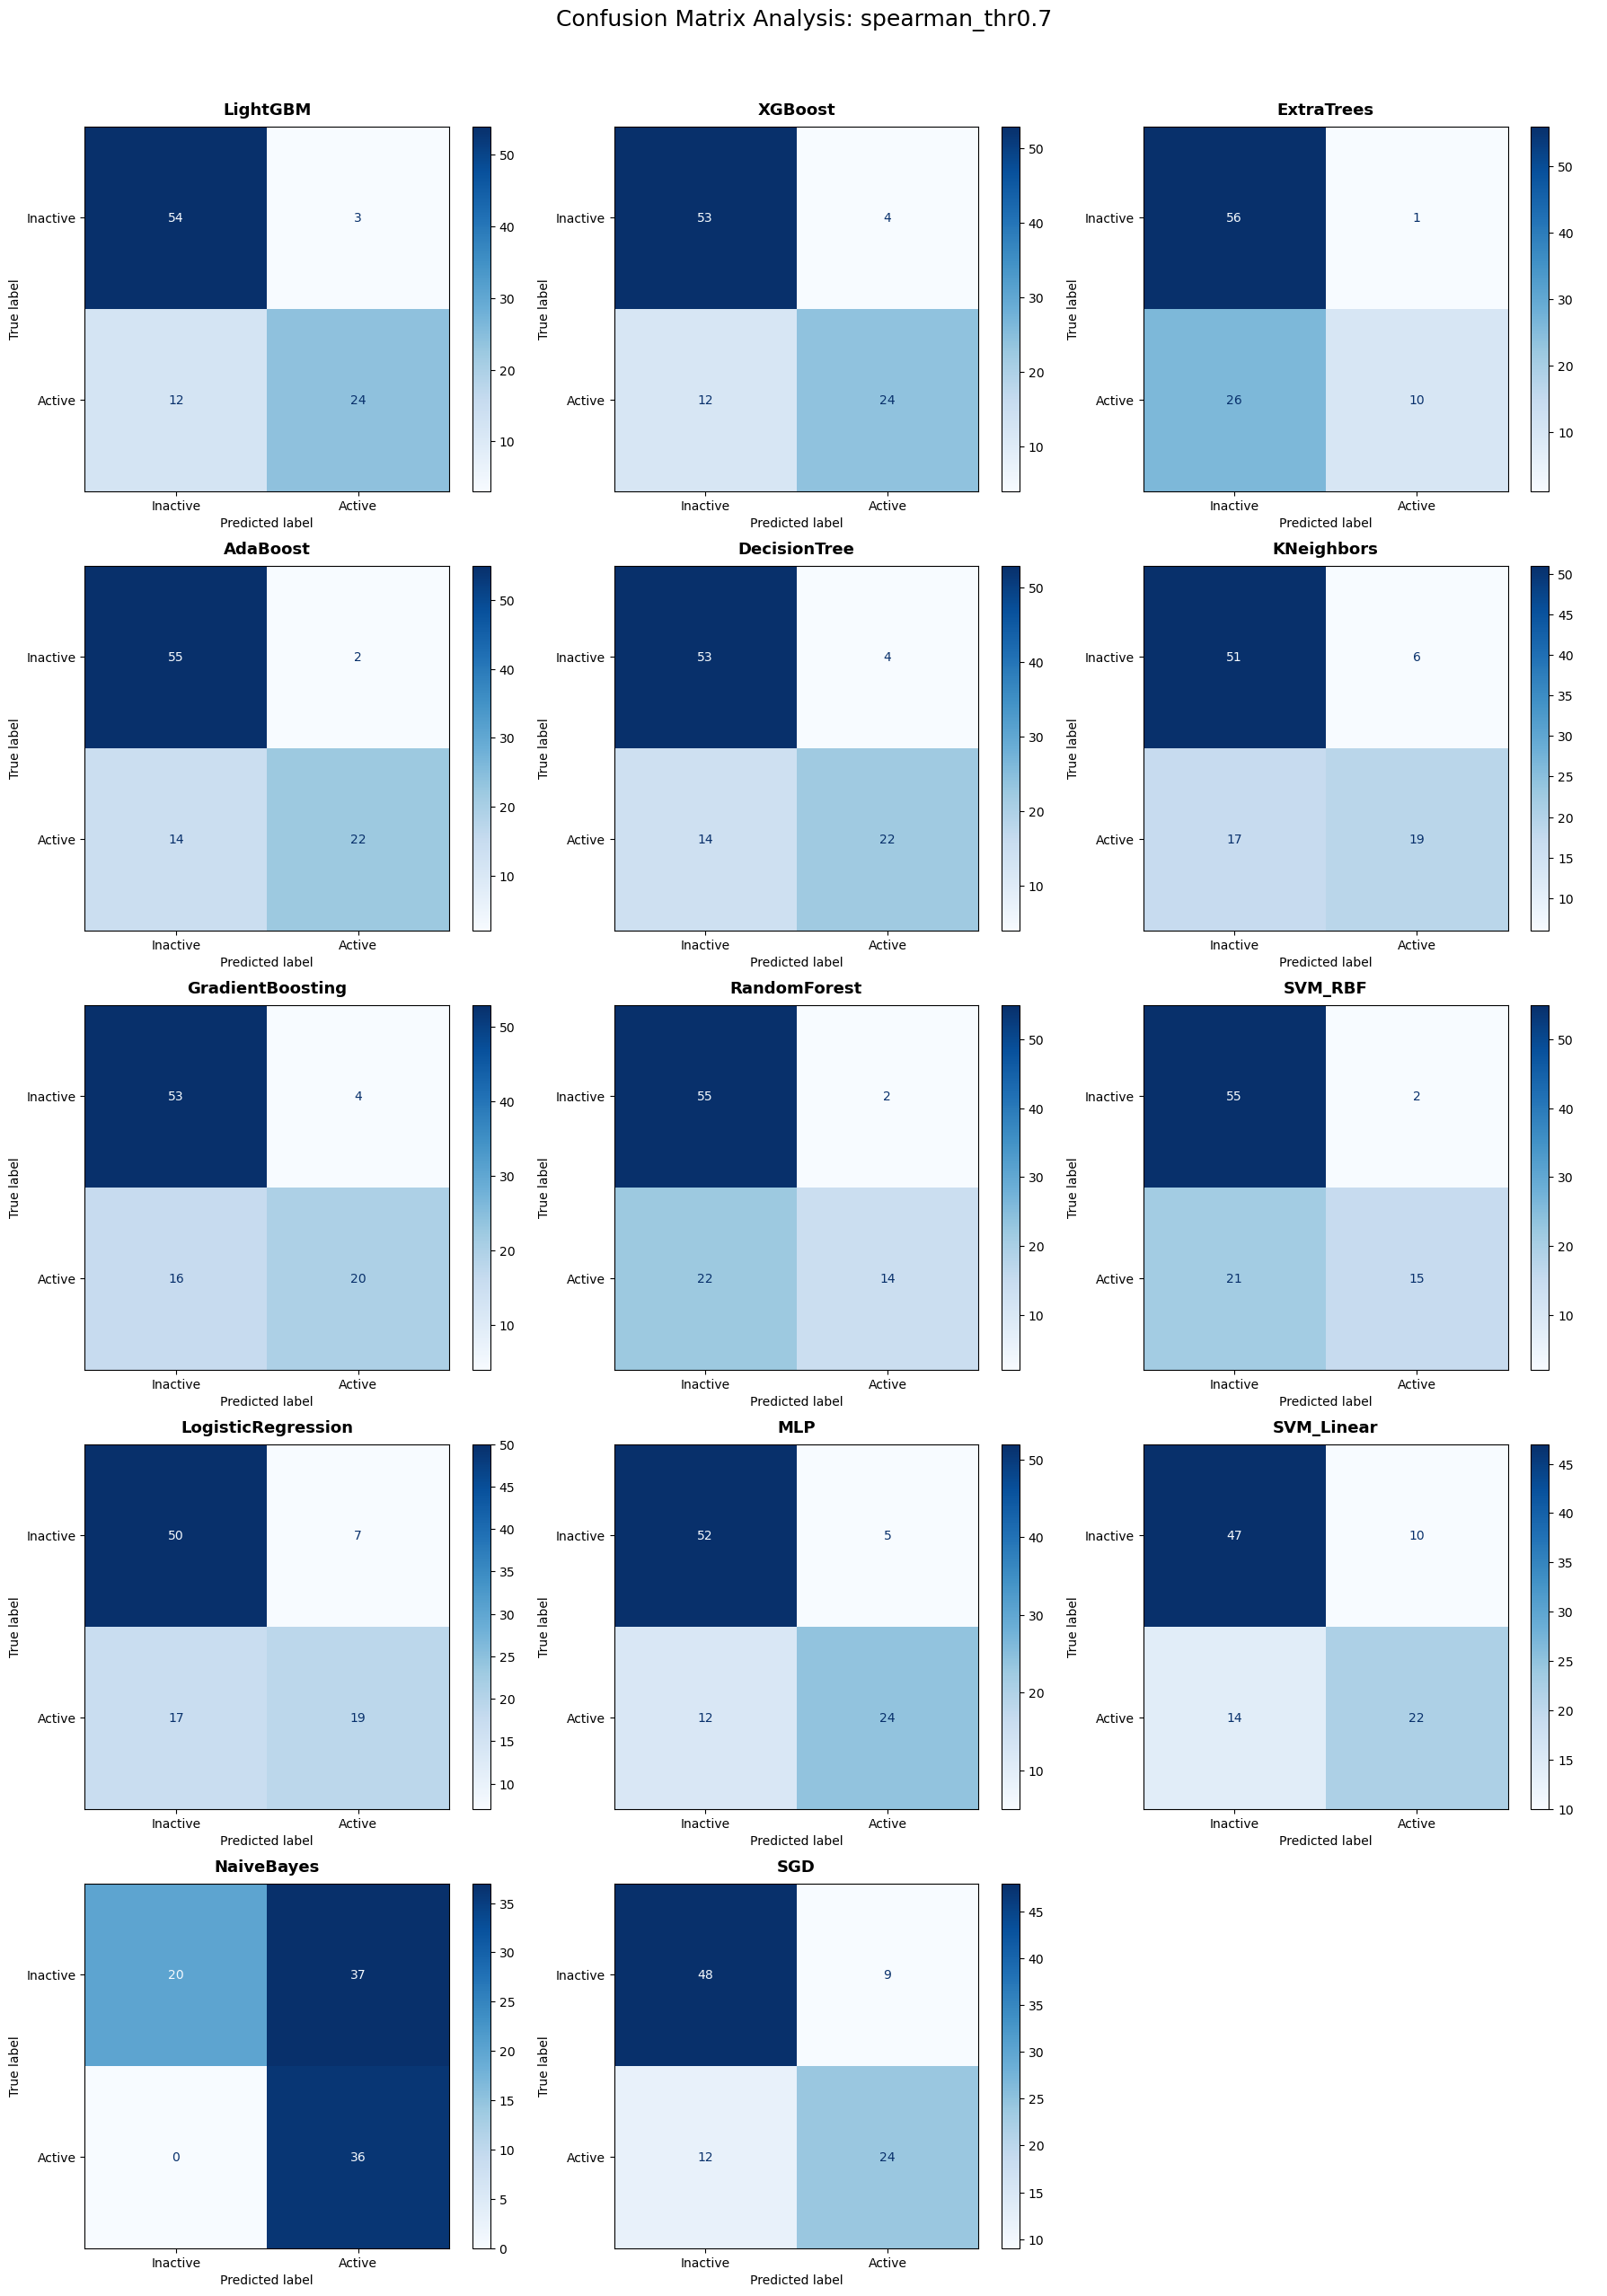

figuras/paso7_confusion_spearman_thr0.7_mordred.png guardado.


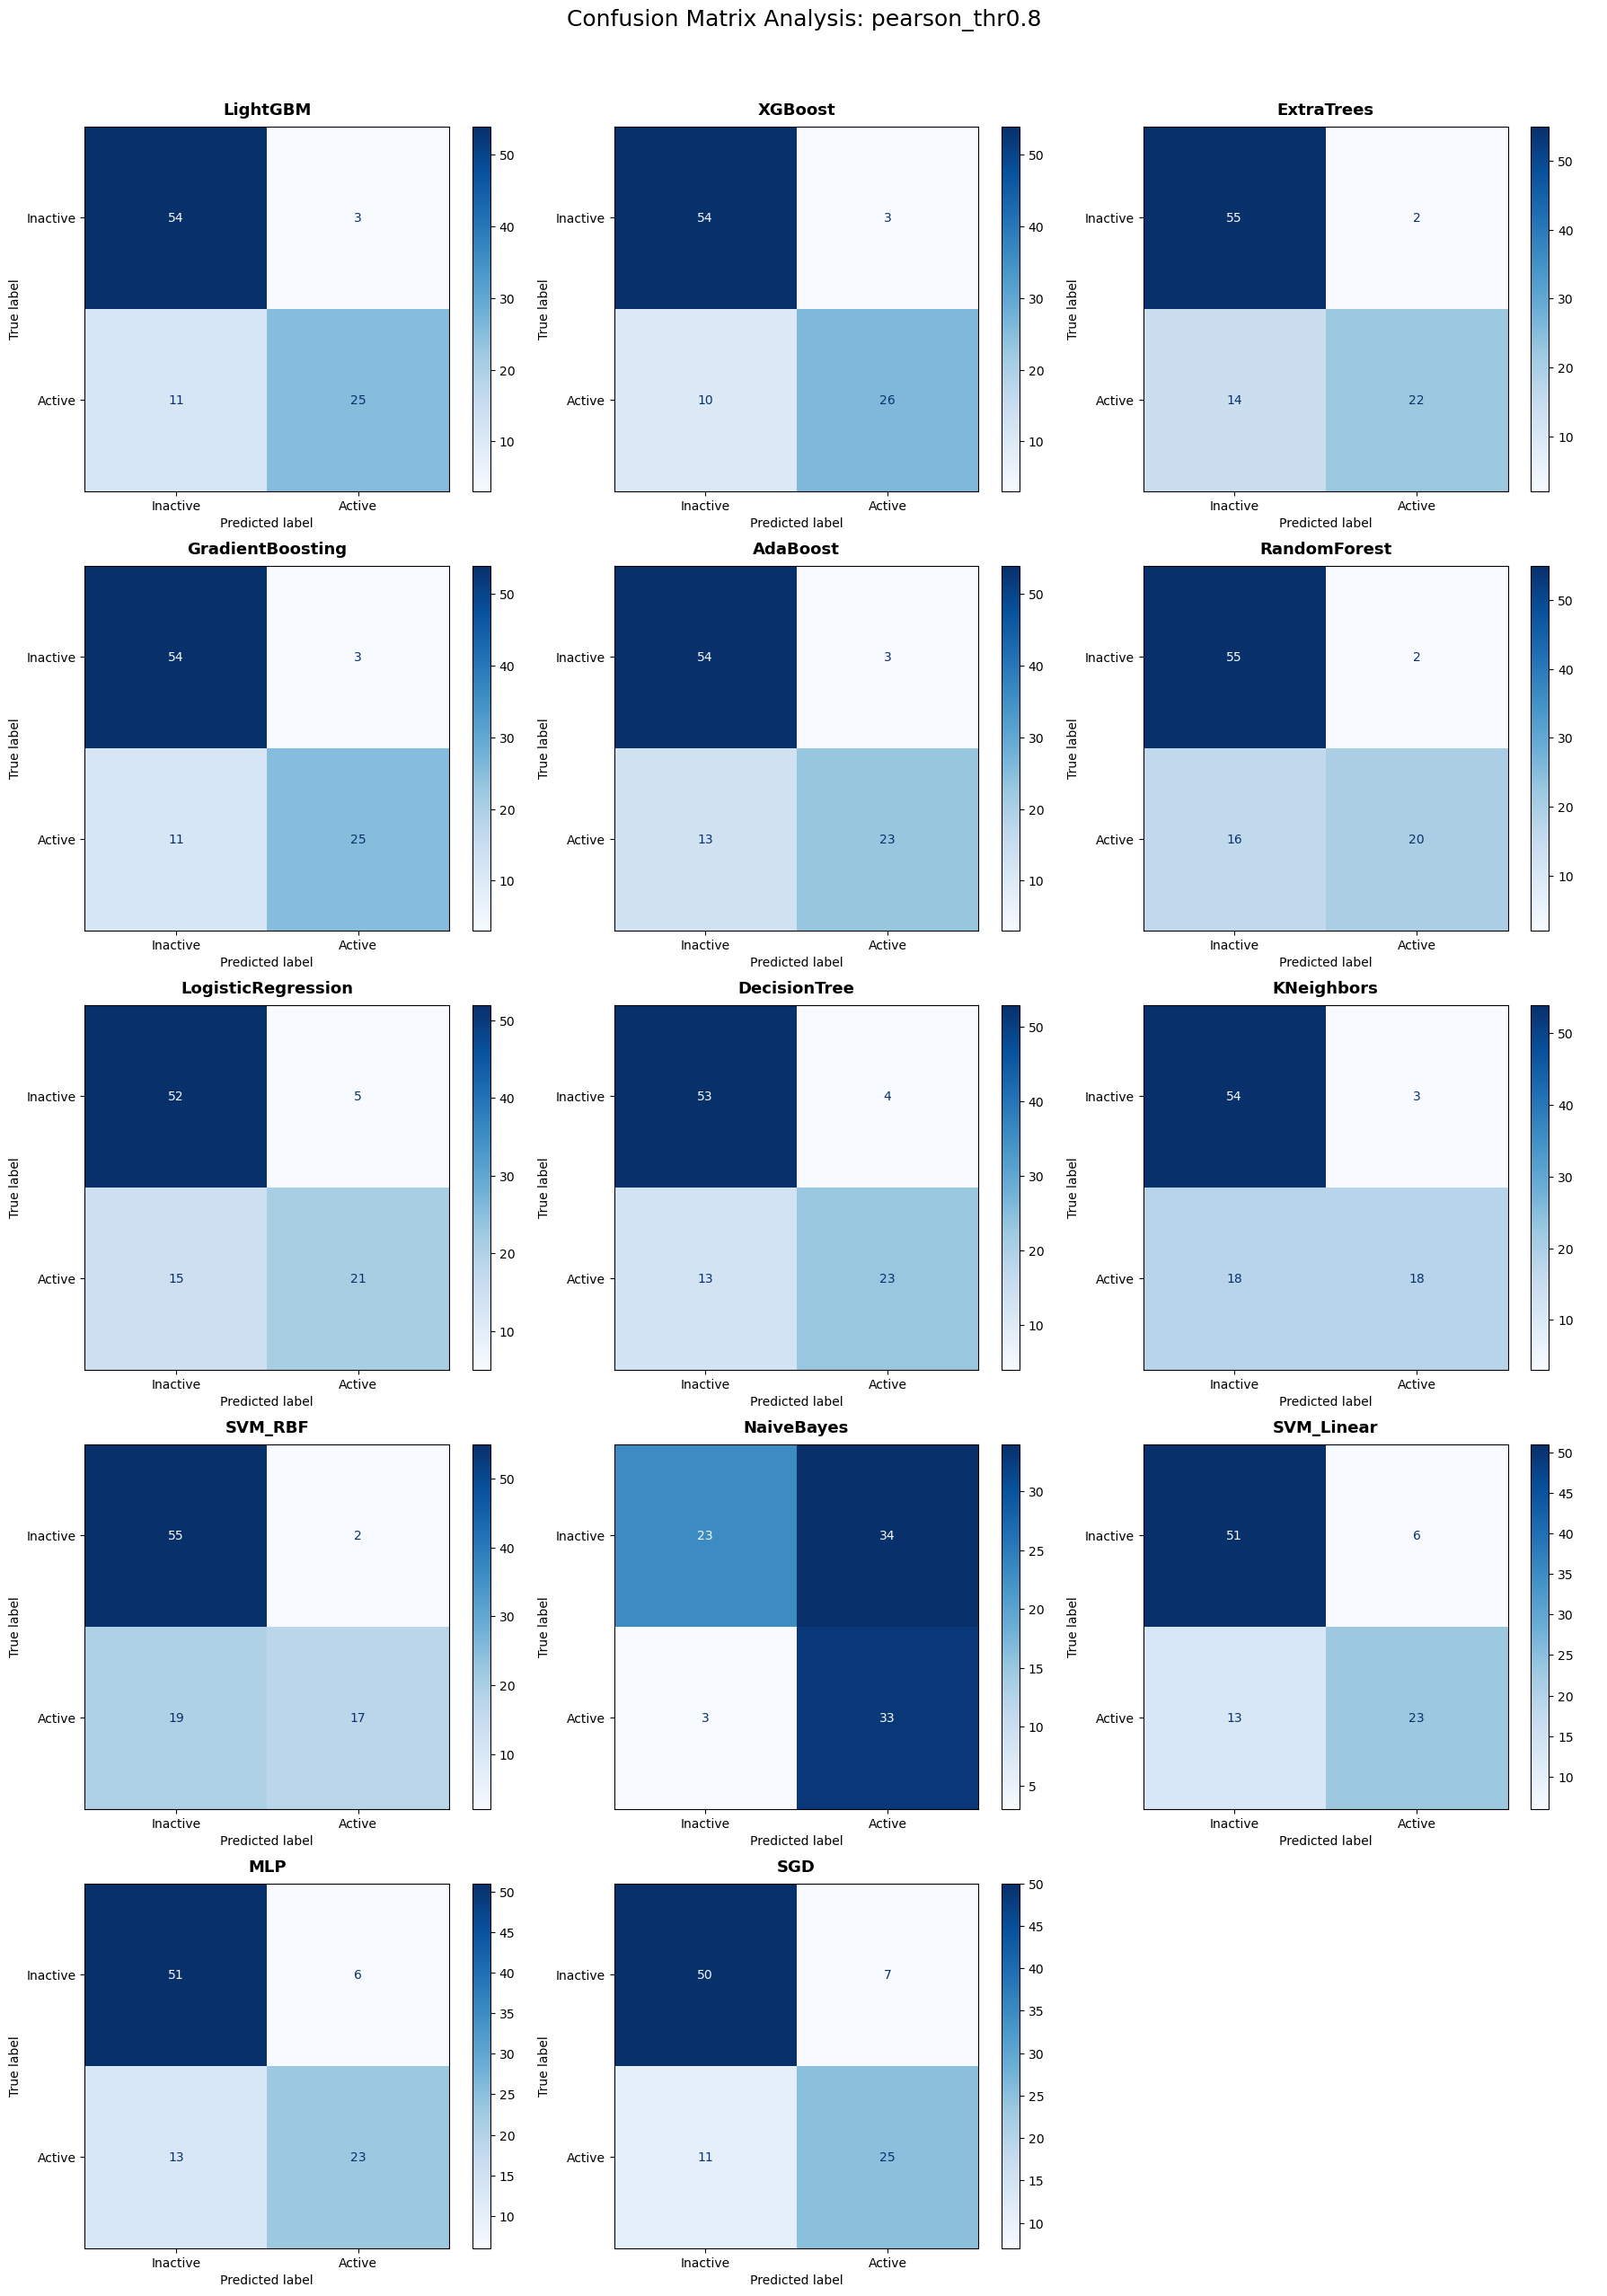

figuras/paso7_confusion_pearson_thr0.8_mordred.png guardado.


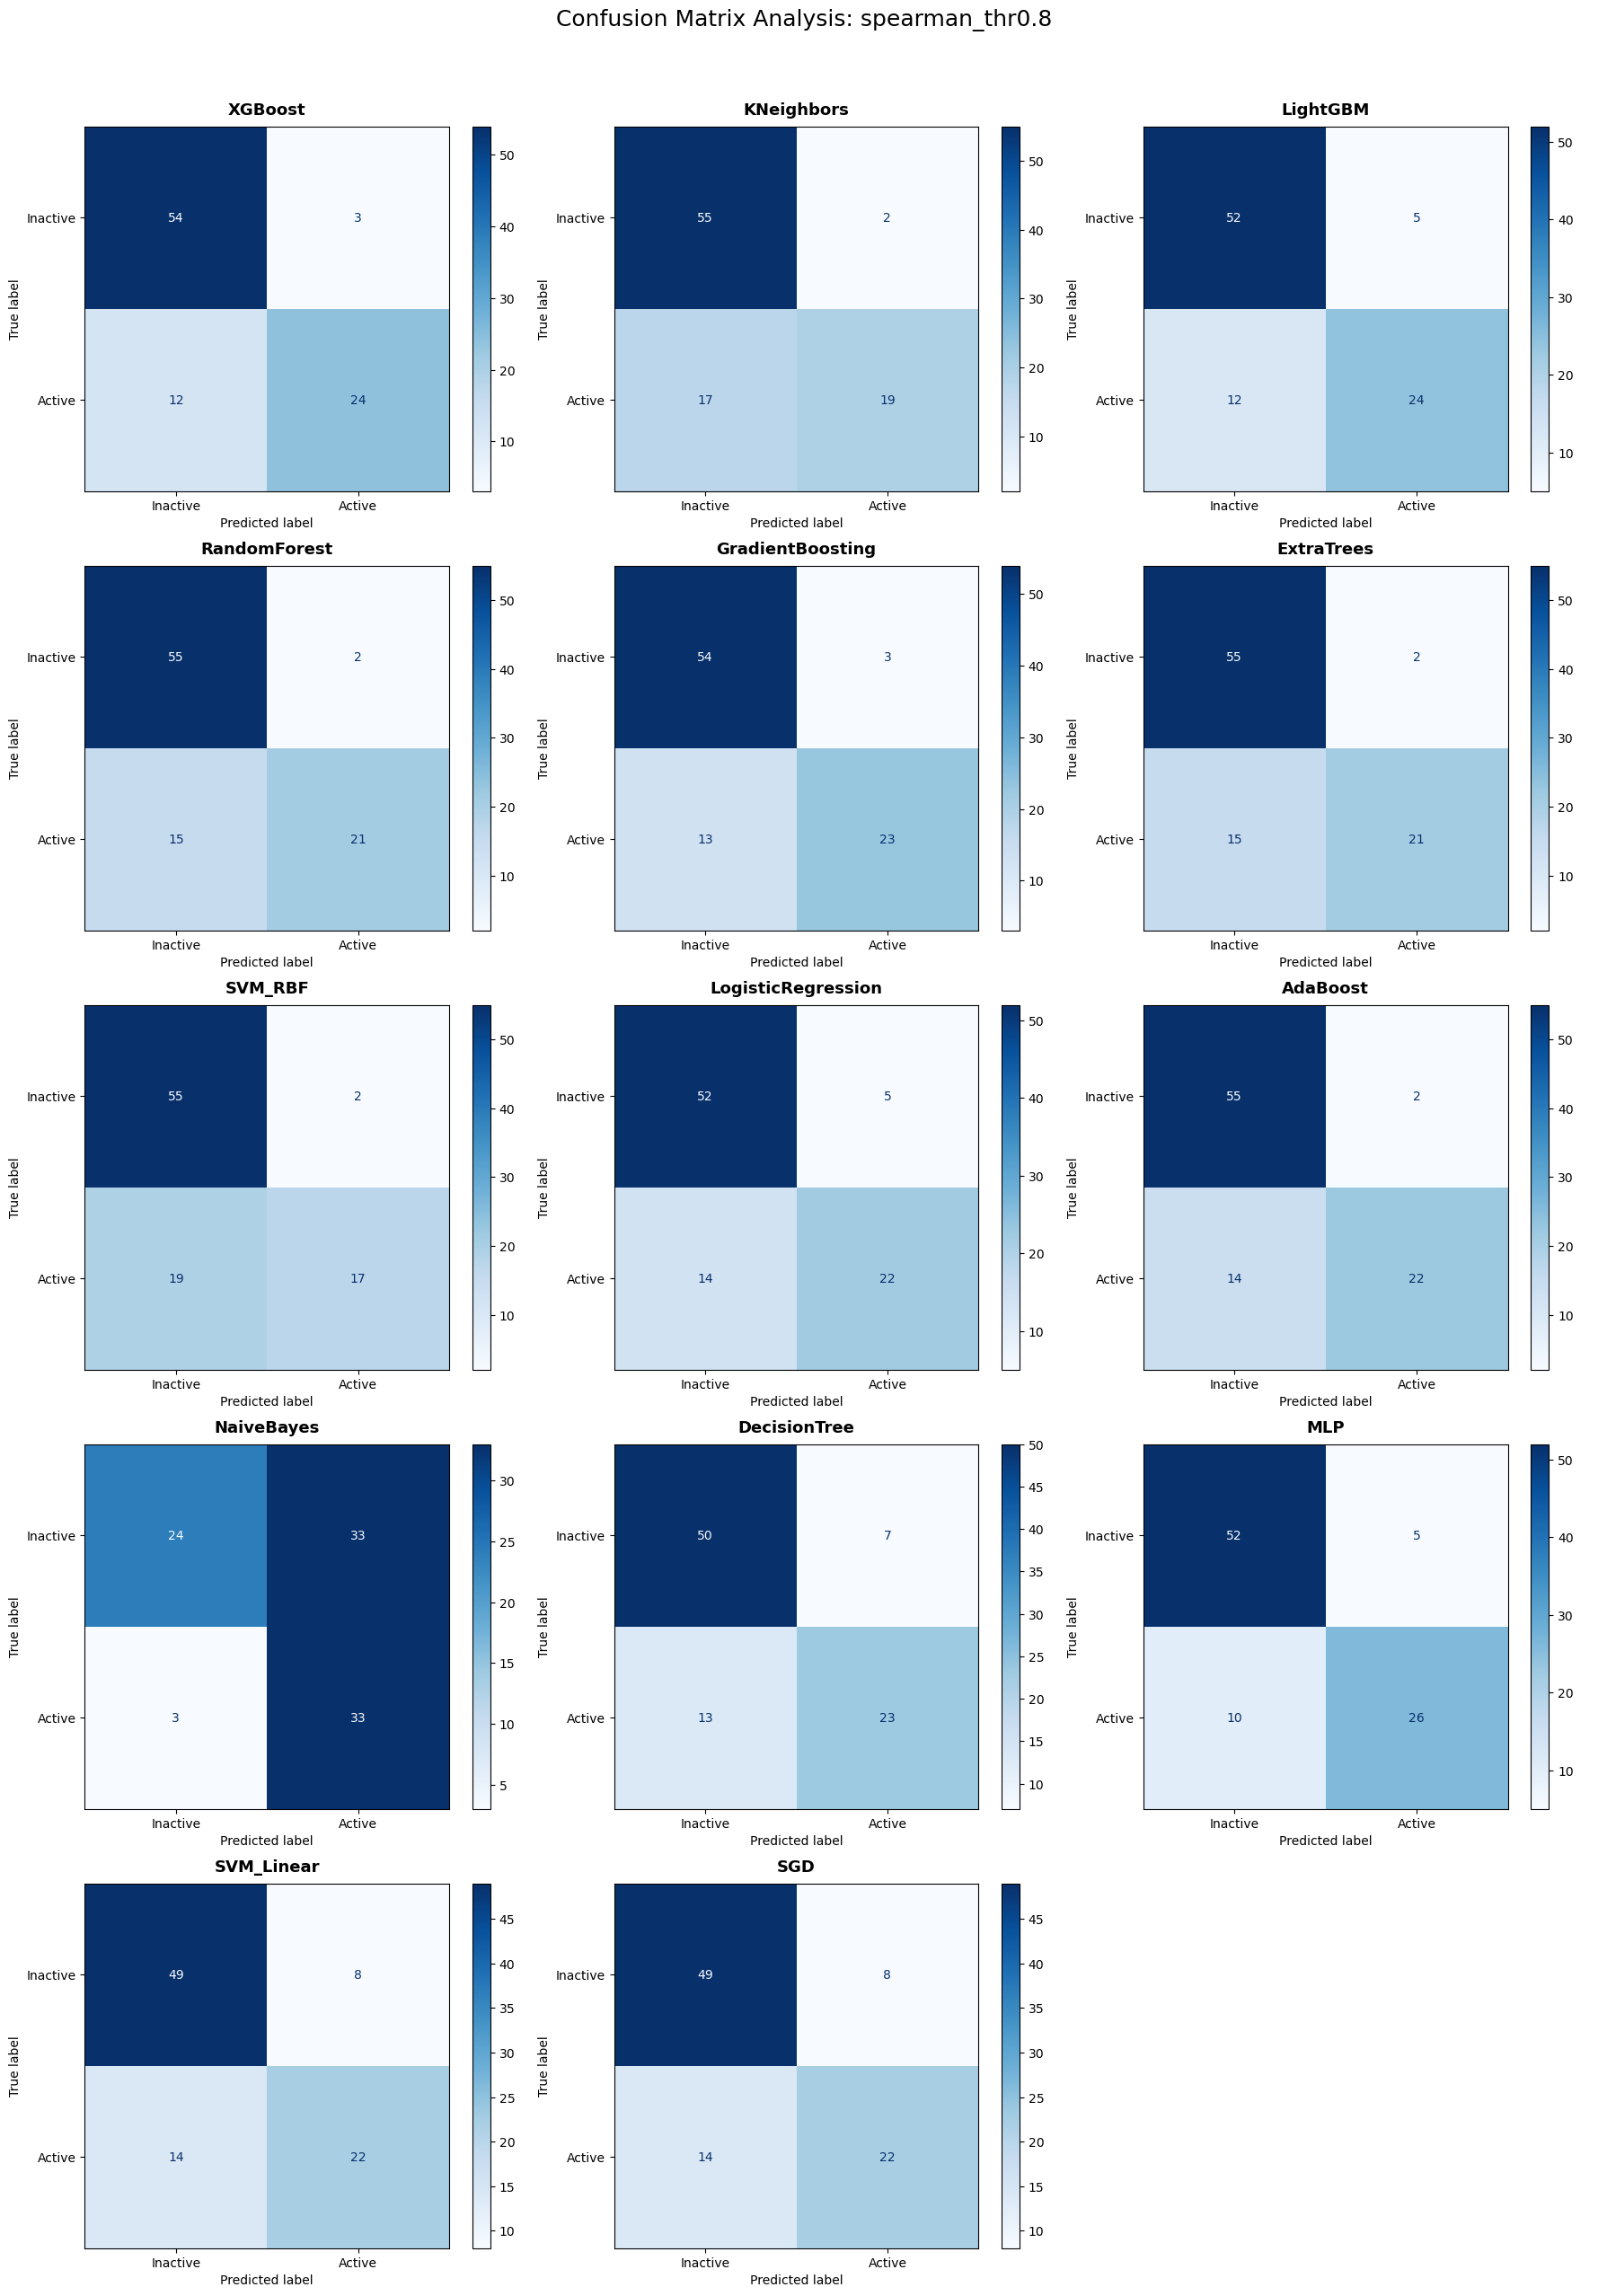

figuras/paso7_confusion_spearman_thr0.8_mordred.png guardado.


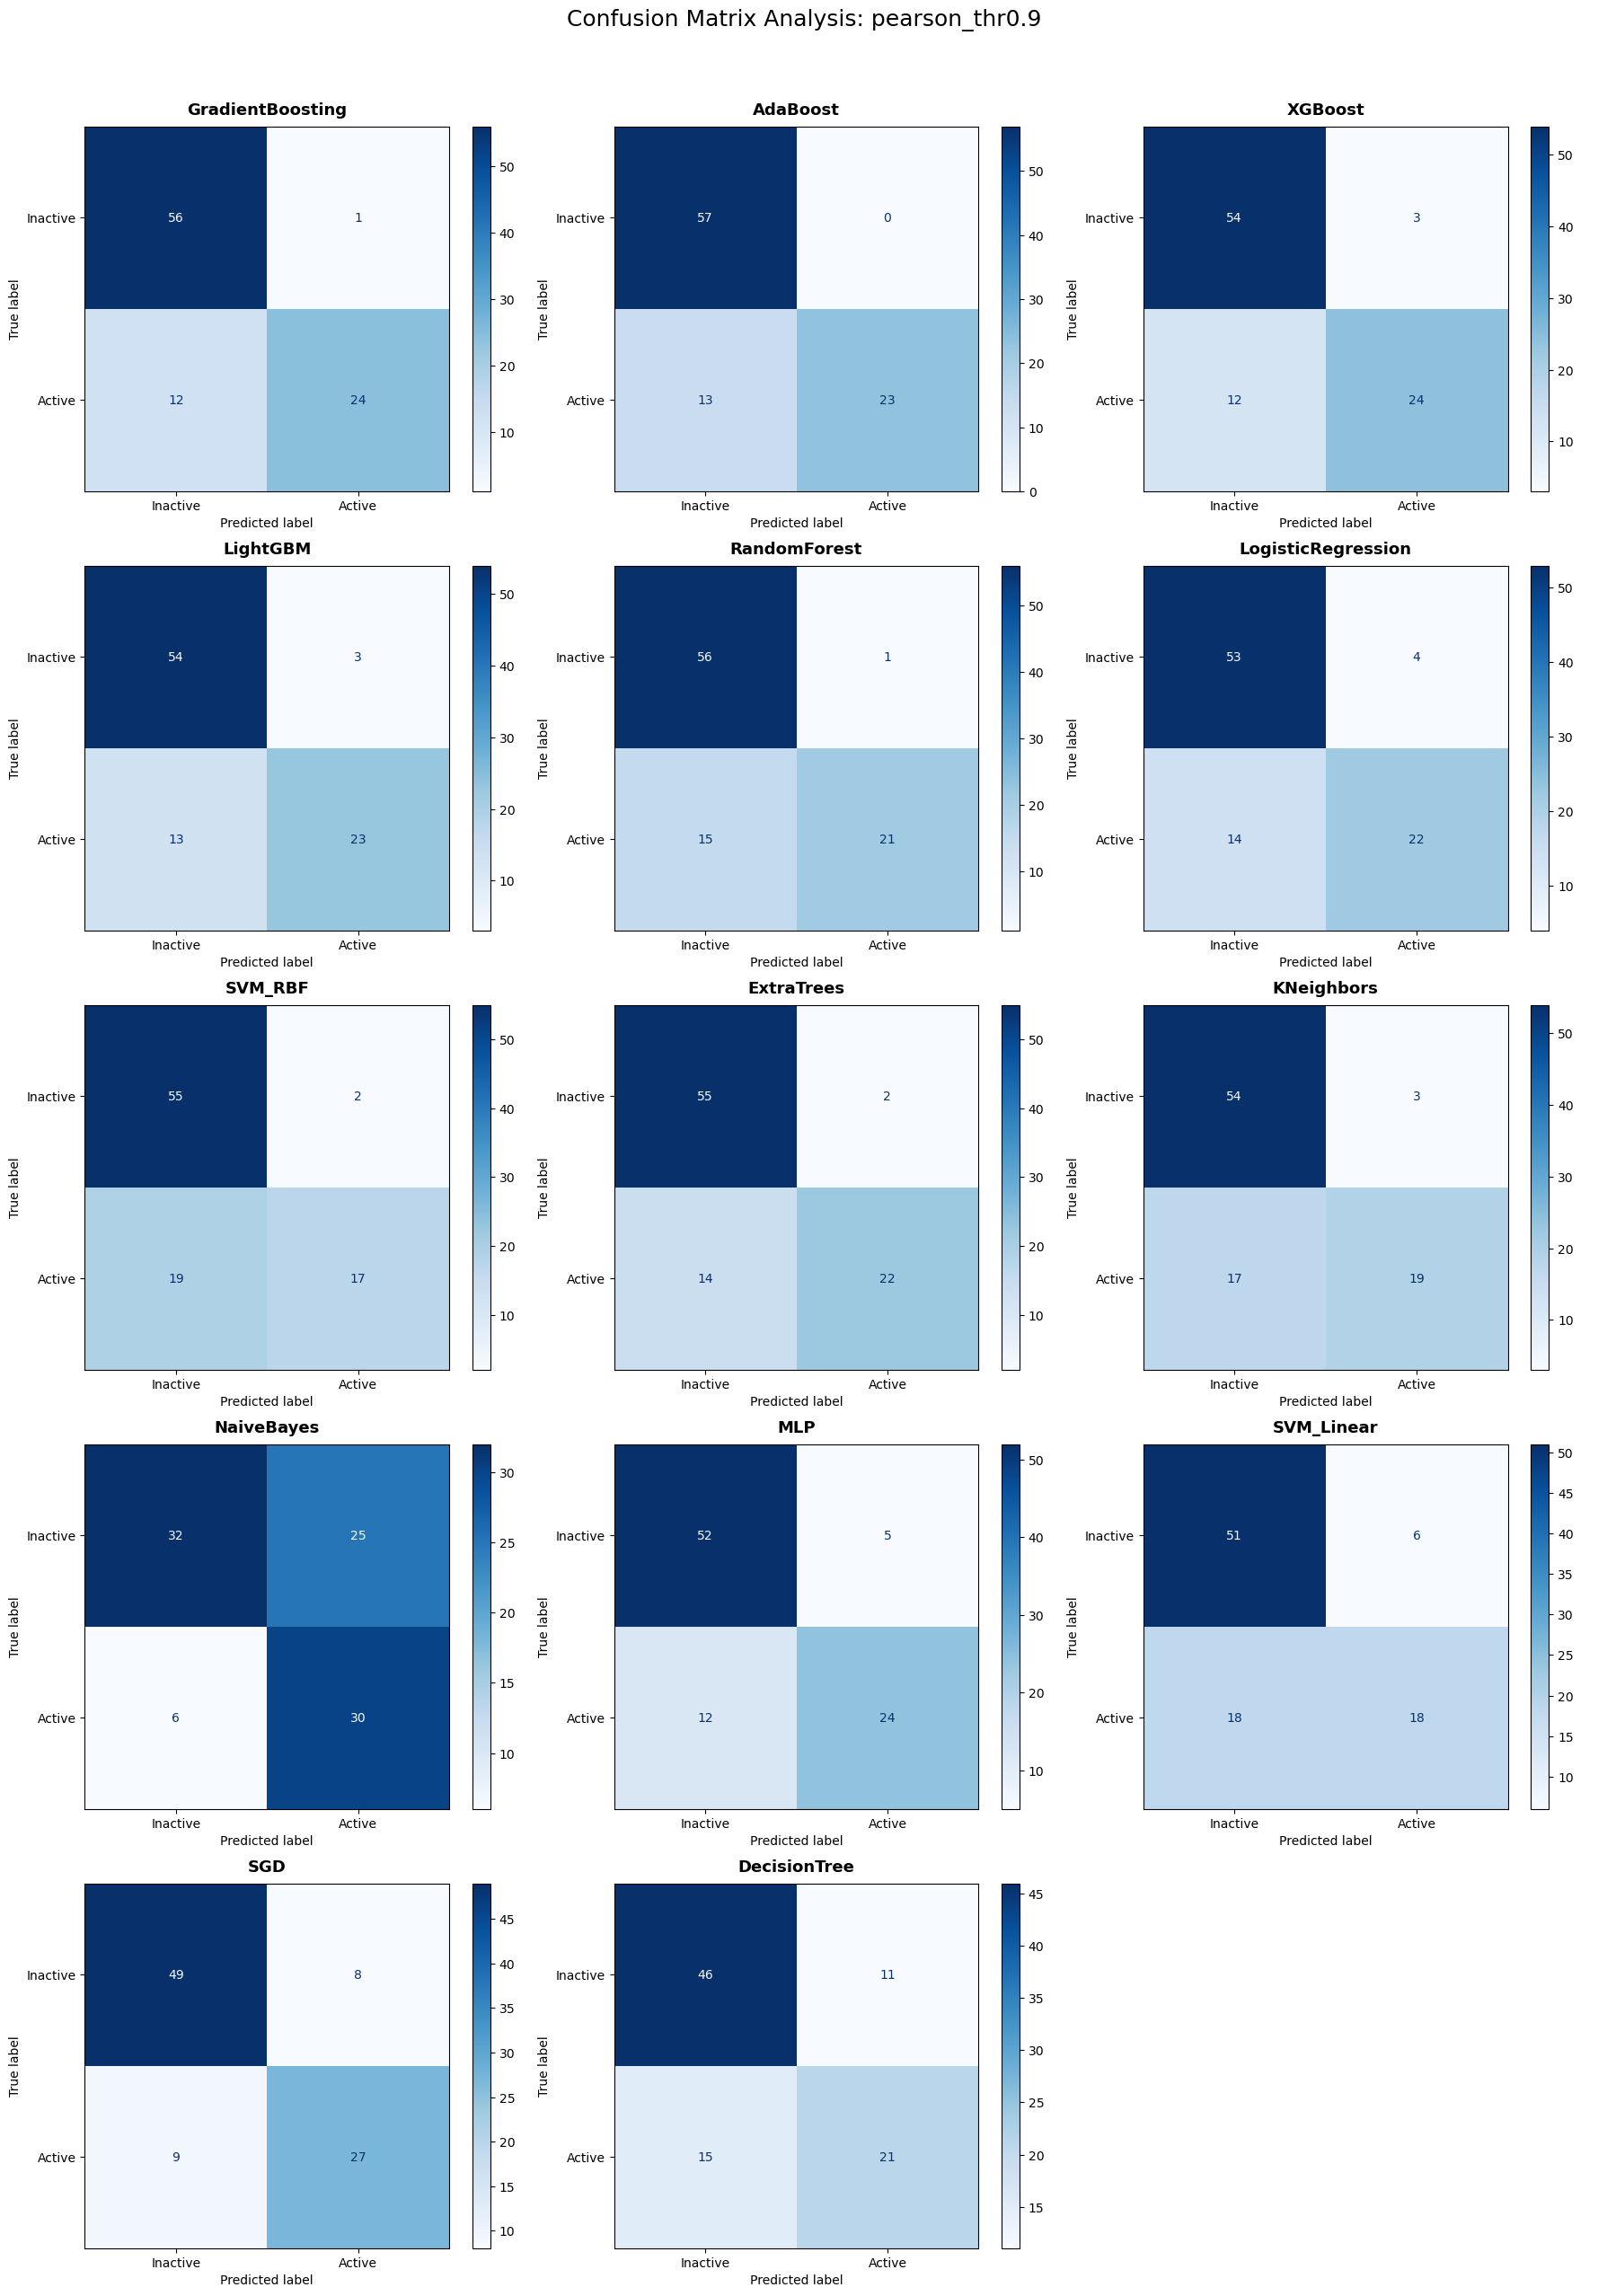

figuras/paso7_confusion_pearson_thr0.9_mordred.png guardado.


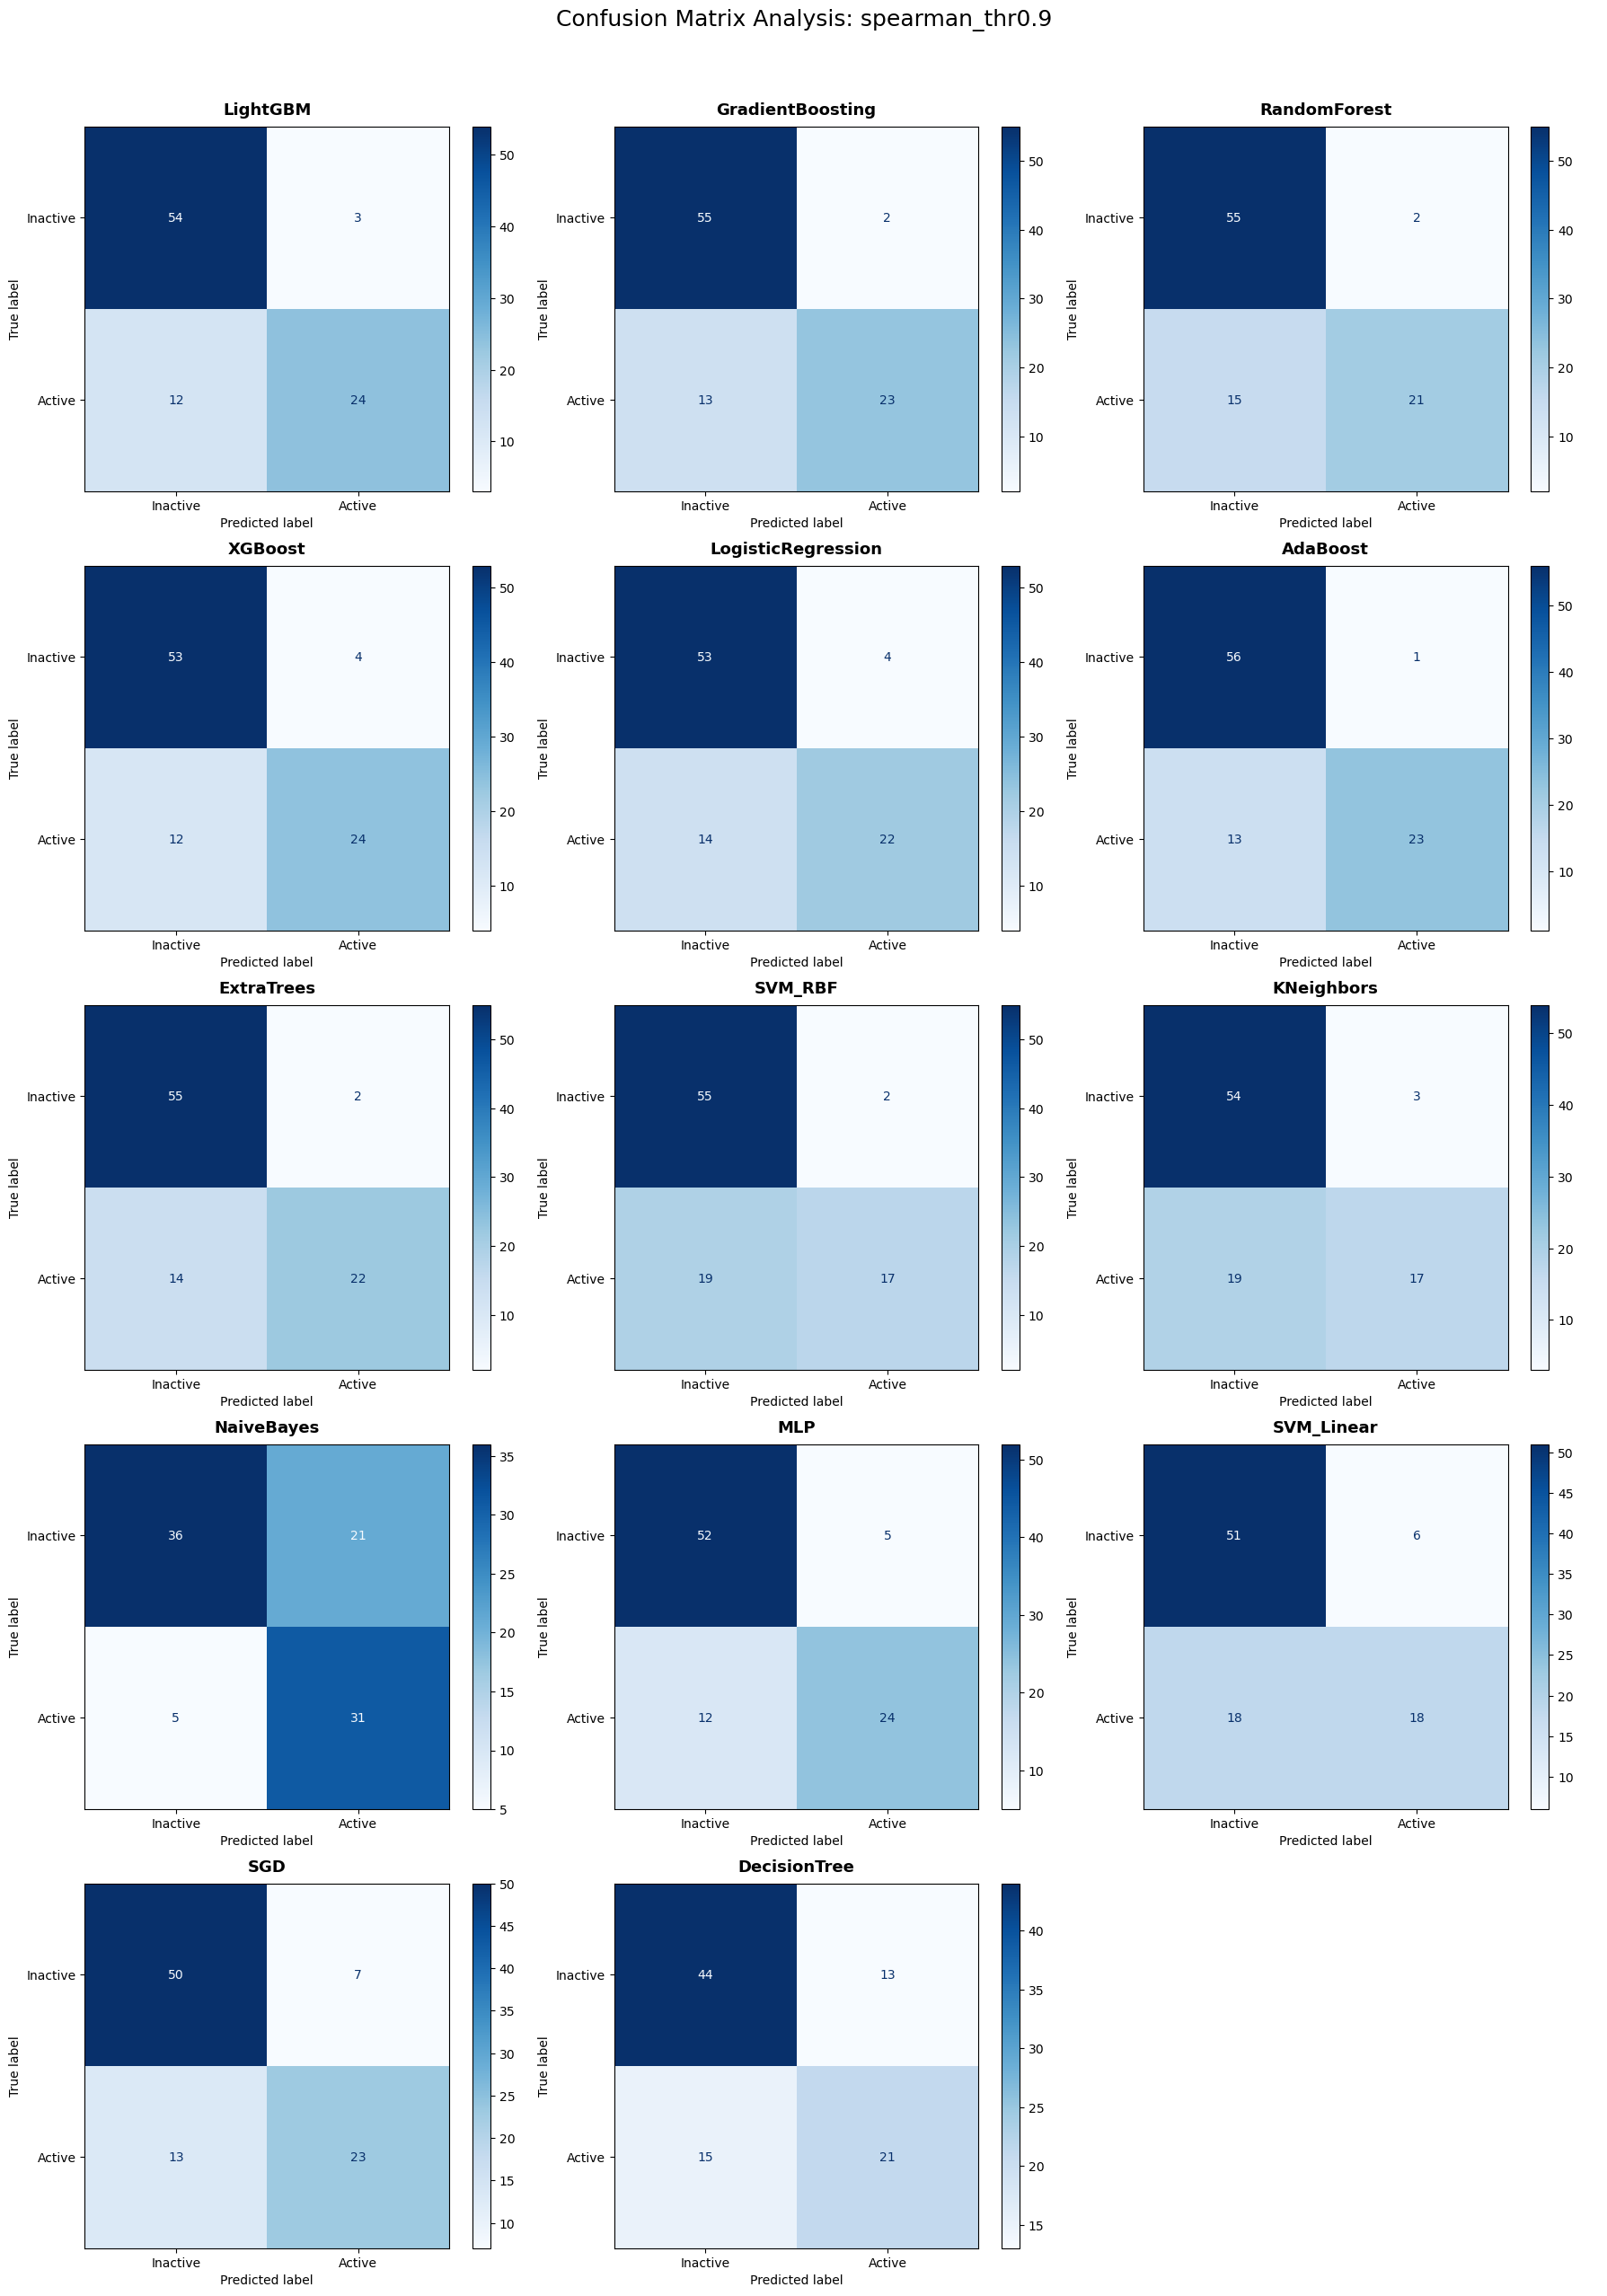

figuras/paso7_confusion_spearman_thr0.9_mordred.png guardado.


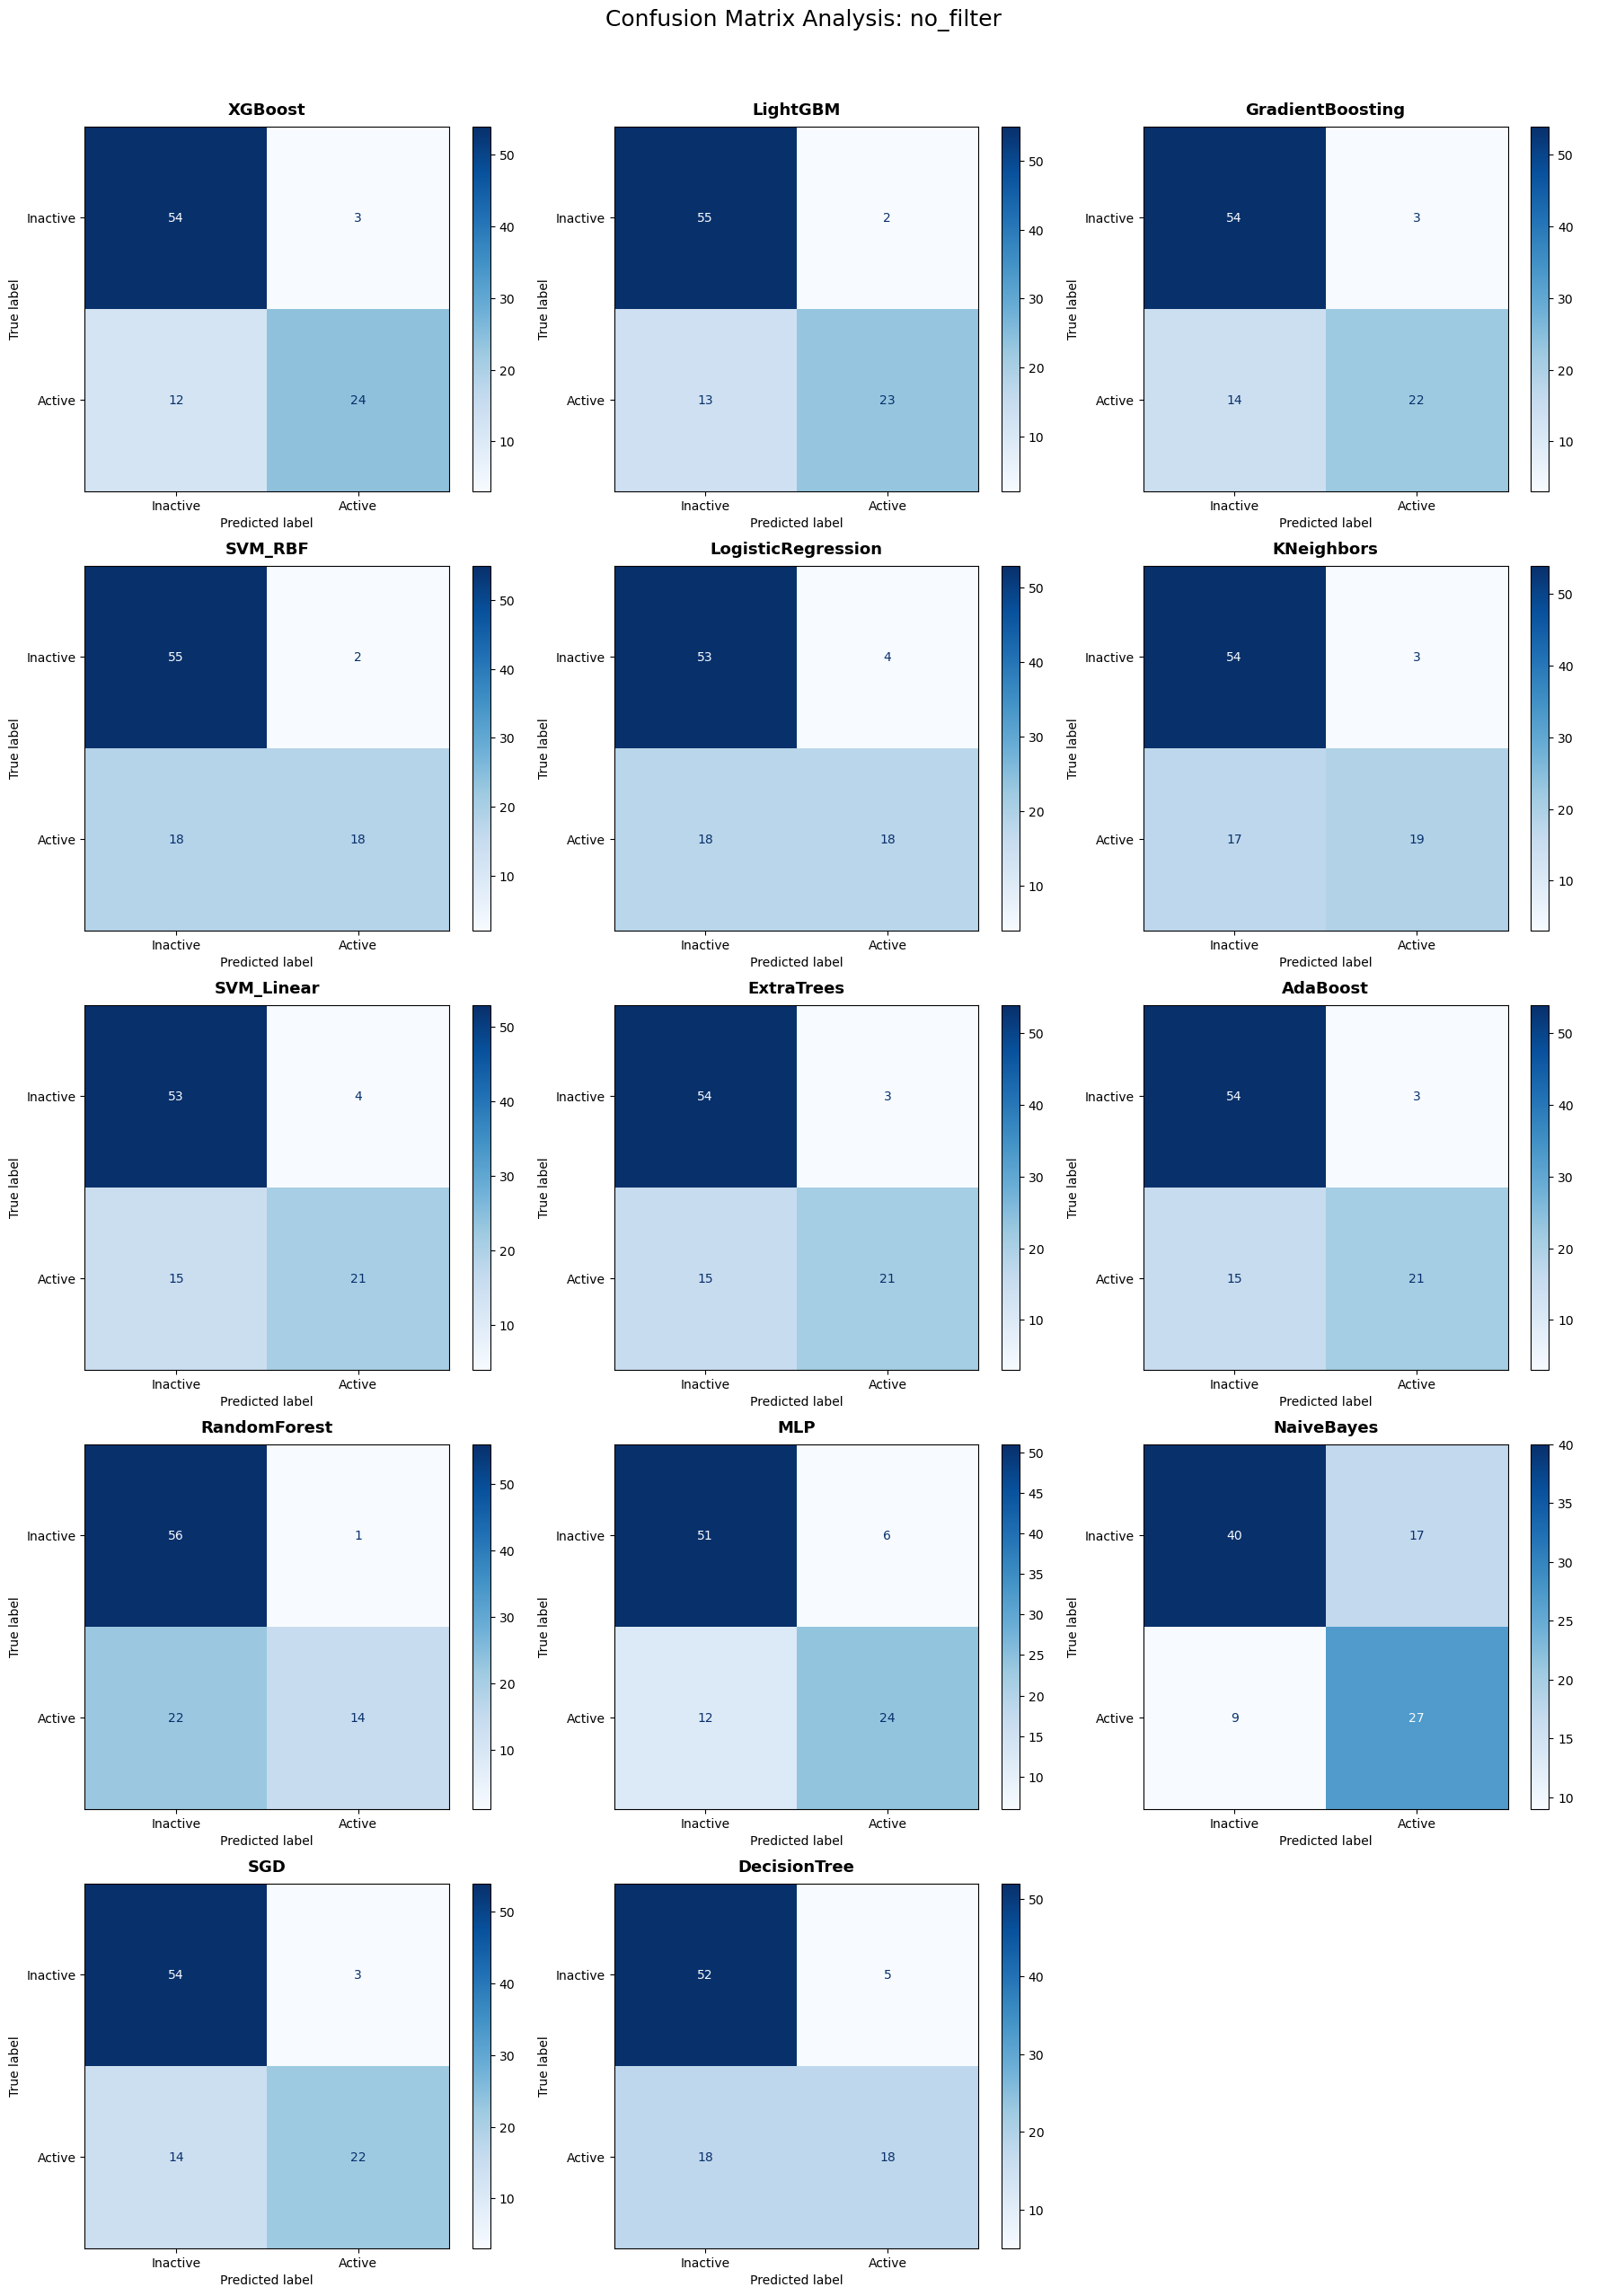

figuras/paso7_confusion_no_filter_mordred.png guardado.


In [19]:
def plot_matrices_by_feature_set(fs_name, results_df, estimators_dict, feature_sets_dict):
    fs_results = results_df[results_df["feature_set"] == fs_name]
    n_models = len(fs_results)
    if n_models == 0:
        return
    cols = 3
    rows = math.ceil(n_models / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
    axes = np.array(axes).reshape(-1)
    for i, (_, row) in enumerate(fs_results.iterrows()):
        model_name = row['model']
        key = f"{model_name}__{fs_name}"
        est = estimators_dict[key]
        fs_cols_local = feature_sets_dict[fs_name]
        y_pred = est.predict(X_test_full[fs_cols_local])
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(cm, display_labels=["Inactive", "Active"])
        disp.plot(ax=axes[i], colorbar=True, cmap="Blues")
        axes[i].set_title(f"{model_name}", fontsize=13, pad=10, fontweight='bold')
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    plt.suptitle(f"Confusion Matrix Analysis: {fs_name}", fontsize=18, y=1.02)
    plt.tight_layout()
    plt.savefig(f'{FIGURAS}/paso7_confusion_{fs_name}_mordred.png', dpi=150, bbox_inches="tight")
    plt.show()
    print(f"{FIGURAS}/paso7_confusion_{fs_name}_mordred.png guardado.")

# Una figura por cada uno de los 7 feature sets (pearson/spearman x 0.7/0.8/0.9, + no_filter)
for fs_name in feature_sets.keys():
    plot_matrices_by_feature_set(fs_name, df_results, best_estimators, feature_sets)


## 3.3 Realización de las curvas ROC

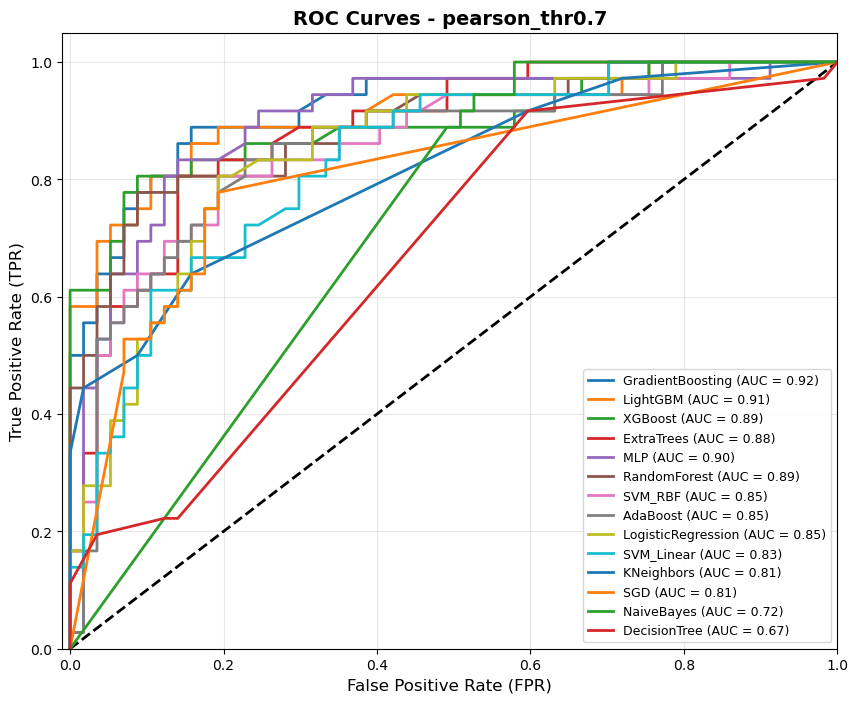

figuras/paso7_roc_comparison_pearson_thr0.7_mordred.png guardado.


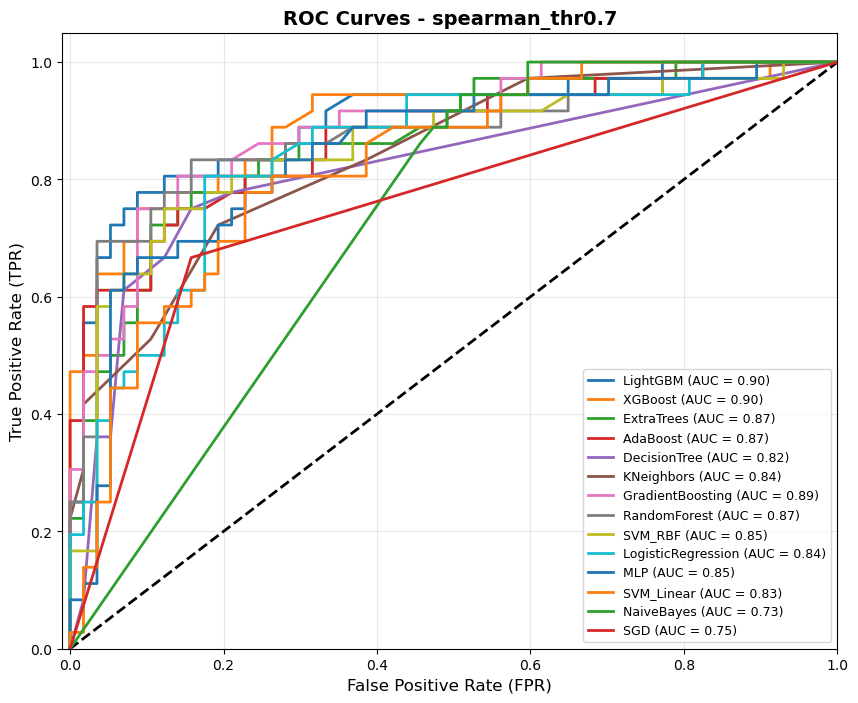

figuras/paso7_roc_comparison_spearman_thr0.7_mordred.png guardado.


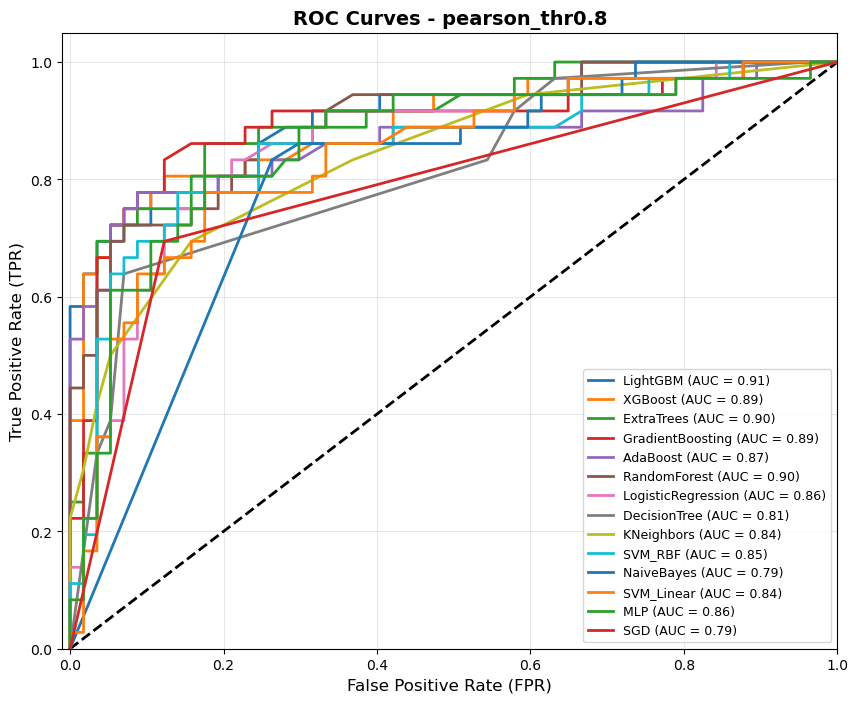

figuras/paso7_roc_comparison_pearson_thr0.8_mordred.png guardado.


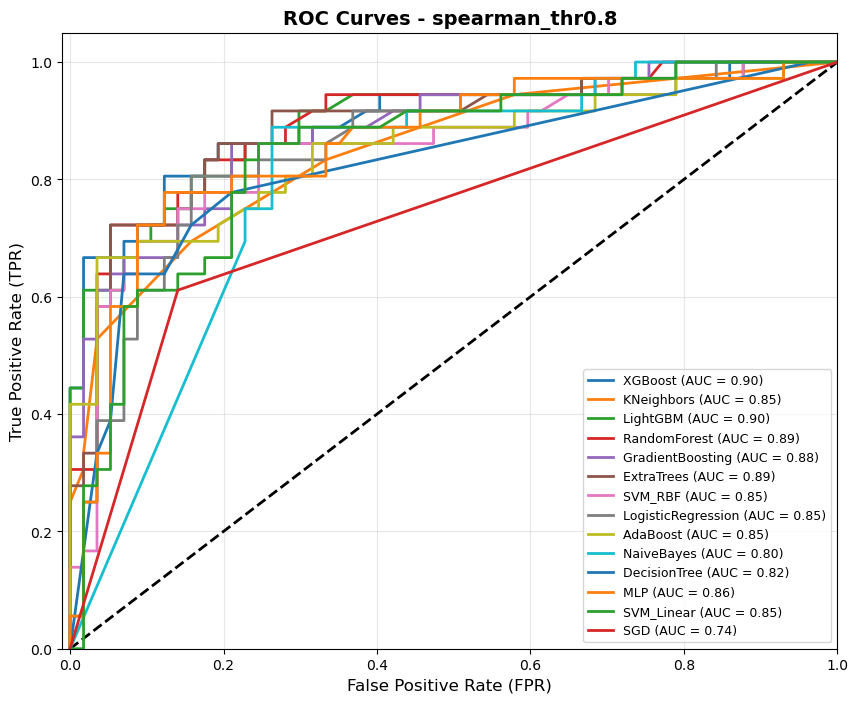

figuras/paso7_roc_comparison_spearman_thr0.8_mordred.png guardado.


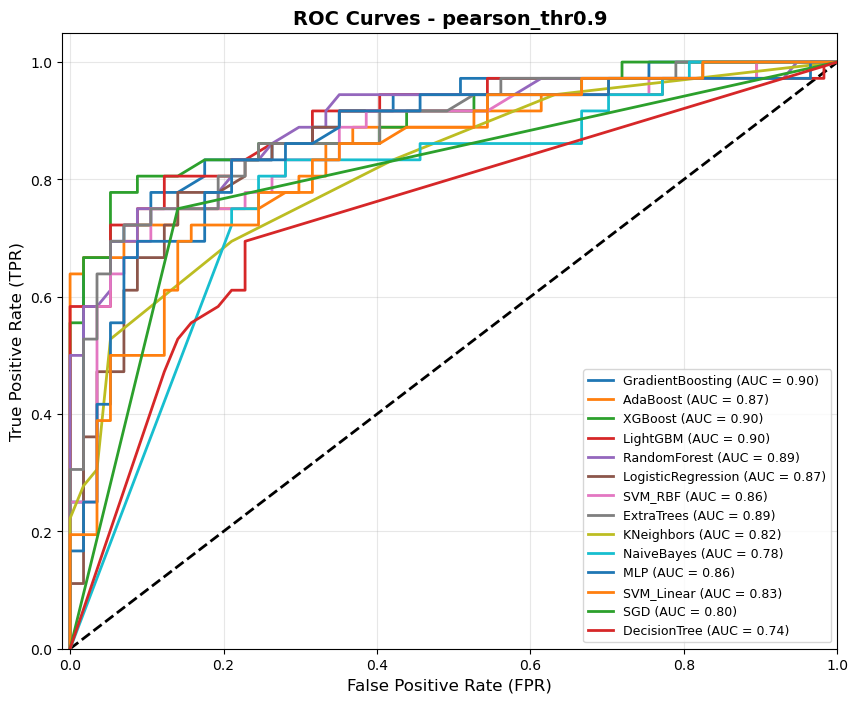

figuras/paso7_roc_comparison_pearson_thr0.9_mordred.png guardado.


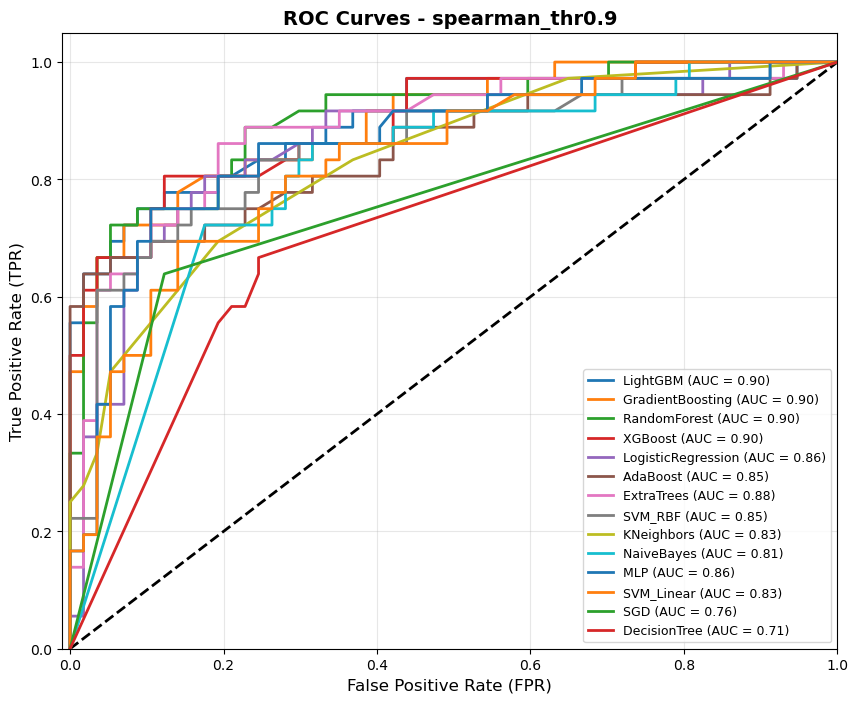

figuras/paso7_roc_comparison_spearman_thr0.9_mordred.png guardado.


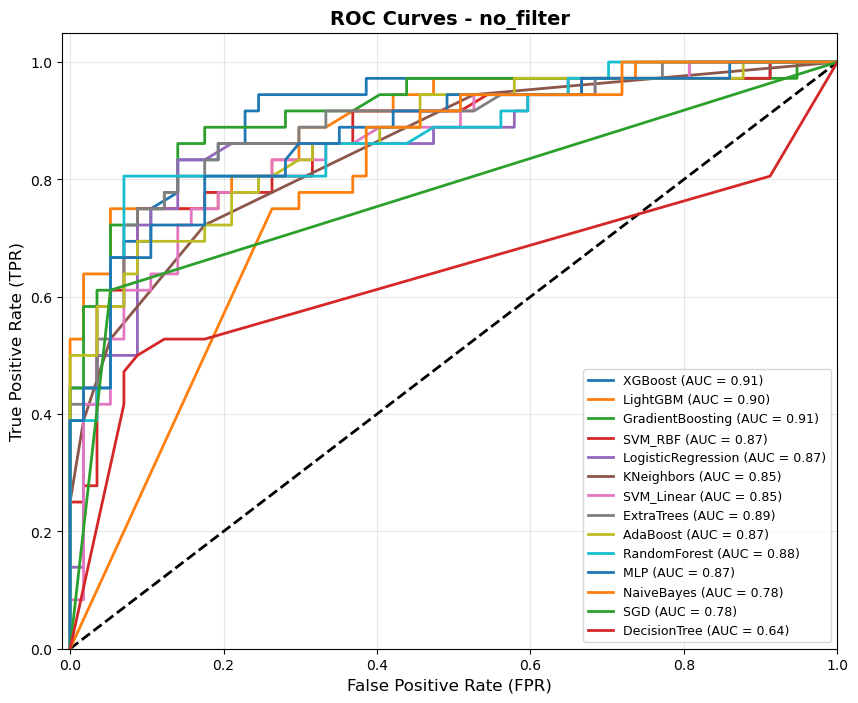

figuras/paso7_roc_comparison_no_filter_mordred.png guardado.


In [20]:
def plot_roc_curves_by_feature_set(fs_name, results_df, estimators_dict, feature_sets_dict):
    fs_results = results_df[results_df["feature_set"] == fs_name]
    if len(fs_results) == 0:
        return
    plt.figure(figsize=(10, 8))
    plt.plot([0, 1], [0, 1], 'k--', lw=2)

    for _, row in fs_results.iterrows():
        model_name = row['model']
        key = f"{model_name}__{fs_name}"
        est = estimators_dict[key]
        fs_cols_local = feature_sets_dict[fs_name]
        if hasattr(est, "predict_proba"):
            y_score = est.predict_proba(X_test_full[fs_cols_local])[:, 1]
        else:
            y_score = est.decision_function(X_test_full[fs_cols_local])
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.2f})')

    plt.xlim([-0.01, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)', fontsize=12)
    plt.ylabel('True Positive Rate (TPR)', fontsize=12)
    plt.title(f'ROC Curves - {fs_name}', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=9)
    plt.grid(alpha=0.3)
    plt.savefig(f'{FIGURAS}/paso7_roc_comparison_{fs_name}_mordred.png', dpi=150, bbox_inches="tight")
    plt.show()
    print(f"{FIGURAS}/paso7_roc_comparison_{fs_name}_mordred.png guardado.")

# Una figura por cada uno de los 7 feature sets
for fs_name in feature_sets.keys():
    plot_roc_curves_by_feature_set(fs_name, df_results, best_estimators, feature_sets)


## 3.4 Realización del overfit gap

In [14]:
pivot_gap = df_results.pivot_table(
    index="model", columns="feature_set",
    values="overfit_gap", aggfunc="min"
)
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(pivot_gap, annot=True, fmt=".2f", cmap="RdYlGn_r",
            center=0, ax=ax, linewidths=0.5)
ax.set_title("Overfit Gap (acc_train − acc_test)")
plt.tight_layout()
plt.savefig(f'{FIGURAS}/paso7_overfit_heatmap_mordred.png',
            dpi=150, bbox_inches="tight")
plt.close()

## 3.5 Ranking de los modelos

In [15]:
best_est = best_estimators[best_key]
best_fs  = feature_sets[best_row["feature_set"]]
y_pred   = best_est.predict(X_test_full[best_fs])
 
print(f"\n{'='*60}")
print(f"MEJOR MODELO : {best_row['model']}")
print(f"Feature set  : {best_row['feature_set']} ({int(best_row['n_features'])} descriptores)")
print(f"{'='*60}")
print(classification_report(y_test, y_pred, target_names=["Inactivo", "Activo"]))
print(f"MCC = {matthews_corrcoef(y_test, y_pred):.4f}")
try:
    y_prob = best_est.predict_proba(X_test_full[best_fs])[:, 1]
    print(f"ROC-AUC = {roc_auc_score(y_test, y_prob):.4f}")
except AttributeError:
    pass
 
pd.DataFrame(
    classification_report(y_test, y_pred,
                           target_names=["Inactivo", "Activo"],
                           output_dict=True)
).T.to_csv(f'{OUTPUT_DIR_ML}/paso7_report_mejor_modelo.csv')
 
print(f"\n✅ Gráficos y reportes del paso 7 guardados.")


MEJOR MODELO : GradientBoosting
Feature set  : pearson_thr0.7 (149 descriptores)
              precision    recall  f1-score   support

    Inactivo       0.82      0.95      0.88        57
      Activo       0.89      0.67      0.76        36

    accuracy                           0.84        93
   macro avg       0.85      0.81      0.82        93
weighted avg       0.85      0.84      0.83        93

MCC = 0.6589
ROC-AUC = 0.9240

✅ Gráficos y reportes del paso 7 guardados.


# 4. Dominio de aplicabilidad - Standardization Approach 

DOMINIO DE APLICABILIDAD - Feature set ganador: pearson_thr0.7
Descriptores (k)         : 149
Compuestos train (n)     : 377
Skewness de S_i (train)  : 3.0418  ->  multiplicador = 3.0
Umbral SDC               : 11.5696

Train - dentro del AD    : 369 (97.9%)
Train - fuera del AD     : 8 (2.1%)

Test  - dentro del AD    : 92 (98.9%)
Test  - fuera del AD     : 1 (1.1%)


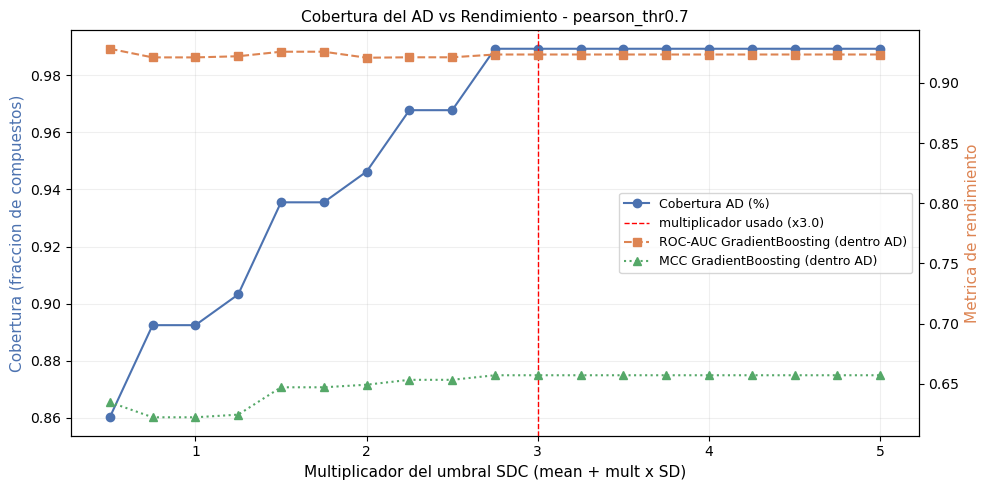

resultados dominio de aplicabilidad mordred/paso8_ad_coverage_pearson_thr0.7_mordred.png guardado.
split  in_AD
test   0          1
       1         92
train  0          8
       1        369
resultados dominio de aplicabilidad mordred/paso8_standardization_pearson_thr0.7_mordred.csv guardado.

[1/3] MODELO: GradientBoosting  |  Feature set: pearson_thr0.7


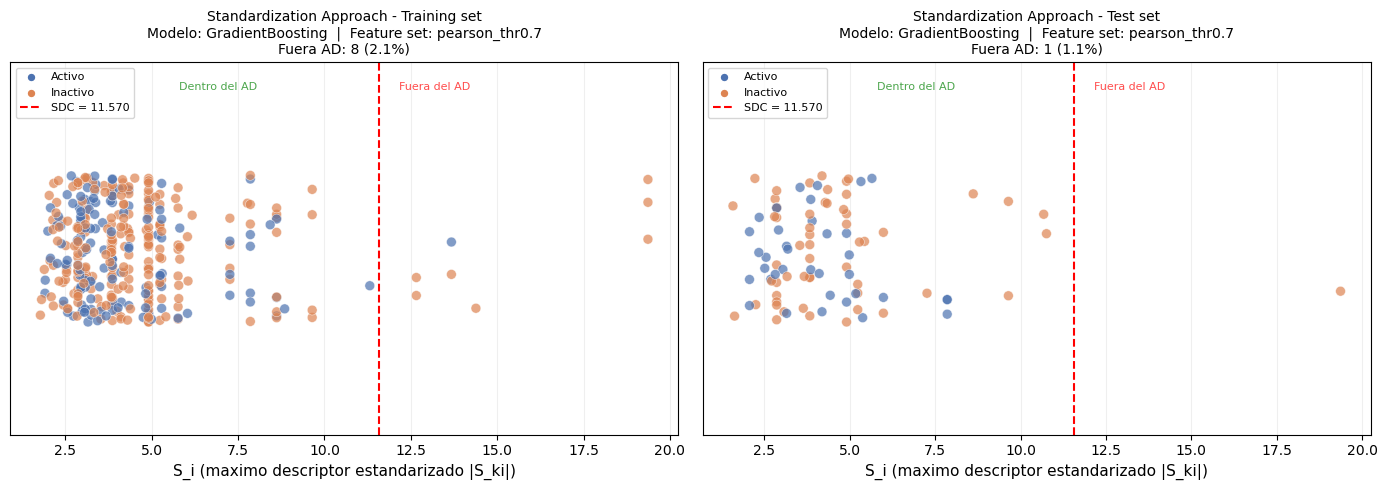

resultados dominio de aplicabilidad mordred/paso8_standardization_plot_top1_GradientBoosting_mordred.png guardado.

-- Test completo (n=93) --
  Accuracy  : 0.8387
  F1        : 0.7619
  MCC       : 0.6589
  ROC-AUC   : 0.9240

-- Test dentro del AD (n=92) --
  Accuracy  : 0.8370
  F1        : 0.7619
  MCC       : 0.6571
  ROC-AUC   : 0.9236

-- Test fuera del AD (n=1) --
  Accuracy  : 1.0000
  F1        : 0.0000
  MCC       : 0.0000
resultados dominio de aplicabilidad mordred/paso8_ad_metrics_top1_GradientBoosting_mordred.csv guardado.

[2/3] MODELO: LightGBM  |  Feature set: pearson_thr0.7


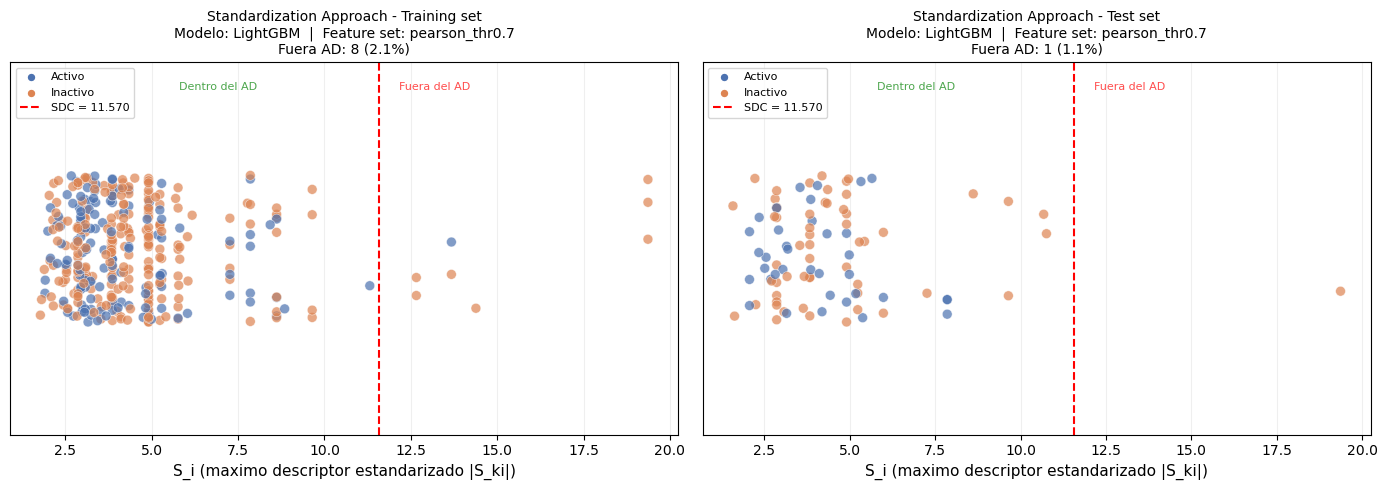

resultados dominio de aplicabilidad mordred/paso8_standardization_plot_top2_LightGBM_mordred.png guardado.

-- Test completo (n=93) --
  Accuracy  : 0.8602
  F1        : 0.7937
  MCC       : 0.7075
  ROC-AUC   : 0.9094

-- Test dentro del AD (n=92) --
  Accuracy  : 0.8587
  F1        : 0.7937
  MCC       : 0.7060
  ROC-AUC   : 0.9097

-- Test fuera del AD (n=1) --
  Accuracy  : 1.0000
  F1        : 0.0000
  MCC       : 0.0000
resultados dominio de aplicabilidad mordred/paso8_ad_metrics_top2_LightGBM_mordred.csv guardado.

[3/3] MODELO: XGBoost  |  Feature set: pearson_thr0.7


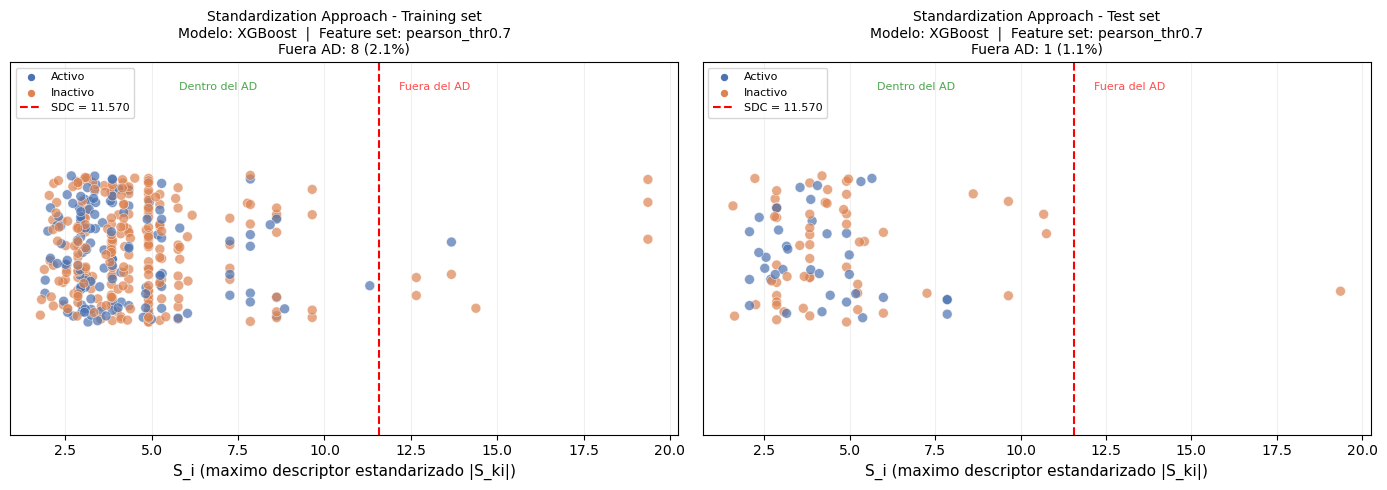

resultados dominio de aplicabilidad mordred/paso8_standardization_plot_top3_XGBoost_mordred.png guardado.

-- Test completo (n=93) --
  Accuracy  : 0.8495
  F1        : 0.7812
  MCC       : 0.6815
  ROC-AUC   : 0.8942

-- Test dentro del AD (n=92) --
  Accuracy  : 0.8478
  F1        : 0.7812
  MCC       : 0.6797
  ROC-AUC   : 0.8948

-- Test fuera del AD (n=1) --
  Accuracy  : 1.0000
  F1        : 0.0000
  MCC       : 0.0000
resultados dominio de aplicabilidad mordred/paso8_ad_metrics_top3_XGBoost_mordred.csv guardado.

RESUMEN COMPARATIVO - TOP 3 MODELOS (mismo AD, distinto clasificador)
 rank            model    feature_set  roc_auc_all  roc_auc_in_AD  mcc_all  mcc_in_AD
    1 GradientBoosting pearson_thr0.7       0.9240         0.9236   0.6589     0.6571
    2         LightGBM pearson_thr0.7       0.9094         0.9097   0.7075     0.7060
    3          XGBoost pearson_thr0.7       0.8942         0.8948   0.6815     0.6797

paraso8_summary_top3_mordred.csv guardado.


In [ ]:
# Referencia: Roy, K., Kar, S., & Ambure, P. (2015). On a simple approach for
# determining applicability domain of QSAR models. Chemometrics and
# Intelligent Laboratory Systems, 145, 22-29.
#
# Este metodo trabaja unicamente sobre la distribucion estadistica de los descriptores 
# estandarizados y no asume ninguna estructura de modelo. Es por tanto aplicable de la misma
# forma a modelos lineales y no lineales (RandomForest, XGBoost, SVM-RBF,
# MLP, etc.) - es agnostico al algoritmo de ML utilizado.
#
# El limite del AD (S_i, SDC) depende solo del feature set (no del modelo),
# asi que se calcula UNA sola vez para el threshold ganador; pero ahora se
# genera un GRAFICO INDIVIDUAL para cada uno de los 3 mejores modelos (misma
# frontera del AD, pero cada figura queda etiquetada e identificada por su
# propio modelo, para poder incluir las tres en el TFM/articulo por separado).
#
# Algoritmo:
#   1. Estandarizar cada descriptor con la media/SD del TRAIN set:
#        S_ki = (P_ki - mean_k) / SD_k
#   2. Para cada compuesto, quedarse con el maximo valor absoluto entre
#      todos sus descriptores estandarizados: S_i = max_k |S_ki|
#   3. Calcular la media y desviacion estandar de los S_i del train, y la
#      asimetria (skewness) de esa distribucion.
#   4. Definir el umbral de corte SDC = mean(S_i) + mult * SD(S_i), con
#      mult = 1.28 si la distribucion es aproximadamente simetrica
#      (|skewness| < 1) o mult = 3.0 si esta sesgada.
#   5. Compuestos (train o test) con S_i > SDC se consideran fuera del AD.

def metrics_summary(y_true, y_pred, y_prob, label):
    print(f"\n-- {label} (n={len(y_true)}) --")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  F1        : {f1_score(y_true, y_pred):.4f}")
    print(f"  MCC       : {matthews_corrcoef(y_true, y_pred):.4f}")
    if len(np.unique(y_true)) > 1:
        print(f"  ROC-AUC   : {roc_auc_score(y_true, y_prob):.4f}")
    return {
        'subset'  : label,
        'n'       : len(y_true),
        'accuracy': accuracy_score(y_true, y_pred),
        'f1'      : f1_score(y_true, y_pred),
        'mcc'     : matthews_corrcoef(y_true, y_pred),
        'roc_auc' : roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
    }

def standardization_approach_ad(X_train: pd.DataFrame, X_test: pd.DataFrame):
    mean_train = X_train.mean()
    std_train  = X_train.std().replace(0, 1)  # evita division por cero en descriptores casi constantes

    S_train = ((X_train - mean_train) / std_train).abs().max(axis=1)
    S_test  = ((X_test  - mean_train) / std_train).abs().max(axis=1)

    skewness = S_train.skew()
    mult = 1.28 if abs(skewness) < 1 else 3.0
    SDC  = S_train.mean() + mult * S_train.std()
    return S_train, S_test, SDC, skewness, mult


def plot_ad_for_model(model_name, S_train, S_test, SDC, best_fs_name, y_train, y_test, model_tag):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (S, y_lbl, split_name) in zip(
        axes,
        [
            (S_train, y_train, 'Training set'),
            (S_test,  y_test,  'Test set'),
        ]
    ):
        out_ad = S > SDC
        colors = np.where(y_lbl == 1, '#4C72B0', '#DD8452')
        jitter = np.random.RandomState(42).uniform(-0.4, 0.4, size=len(S))

        ax.scatter(S, jitter, c=colors, alpha=0.7, edgecolors='white',
                   linewidths=0.4, s=50, zorder=3)
        ax.axvline(SDC, color='red', linestyle='--', linewidth=1.5, label=f'SDC = {SDC:.3f}')
        ax.set_ylim(-1, 1)
        ax.set_yticks([])
        ax.text(SDC * 0.5, 0.85, 'Dentro del AD', fontsize=8, color='green', alpha=0.7)
        ax.text(SDC * 1.05, 0.85, 'Fuera del AD',  fontsize=8, color='red',   alpha=0.7)

        legend_patches = [
            plt.scatter([], [], c='#4C72B0', s=40, label='Activo',   edgecolors='white'),
            plt.scatter([], [], c='#DD8452', s=40, label='Inactivo', edgecolors='white'),
        ]
        ax.legend(handles=legend_patches + [
            plt.Line2D([0], [0], color='red', linestyle='--', label=f'SDC = {SDC:.3f}'),
        ], fontsize=8, loc='upper left')

        ax.set_xlabel('S_i (maximo descriptor estandarizado |S_ki|)', fontsize=11)
        ax.set_title(
            f'Standardization Approach - {split_name}\n'
            f'Modelo: {model_name}  |  Feature set: {best_fs_name}\n'
            f'Fuera AD: {out_ad.sum()} ({out_ad.mean():.1%})',
            fontsize=10
        )
        ax.grid(alpha=0.2, axis='x')

    plt.tight_layout()
    out_std = f'{OUTPUT_DIR_AD}/paso8_standardization_plot_{model_tag}_mordred.png'
    plt.savefig(out_std, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'{out_std} guardado.')


print("=" * 60)
print(f"DOMINIO DE APLICABILIDAD - Feature set ganador: {best_fs_name}")
print("=" * 60)

fs_cols = feature_sets[best_fs_name]

# ── Standardization approach: se calcula UNA vez para todo el feature set ───
S_train, S_test, SDC, skewness, mult = standardization_approach_ad(
    X_train_full[fs_cols], X_test_full[fs_cols]
)

print(f"Descriptores (k)         : {len(fs_cols)}")
print(f"Compuestos train (n)     : {len(X_train_full)}")
print(f"Skewness de S_i (train)  : {skewness:.4f}  ->  multiplicador = {mult}")
print(f"Umbral SDC               : {SDC:.4f}")
print()
print(f"Train - dentro del AD    : {(S_train <= SDC).sum()} ({(S_train <= SDC).mean():.1%})")
print(f"Train - fuera del AD     : {(S_train >  SDC).sum()} ({(S_train >  SDC).mean():.1%})")
print()
print(f"Test  - dentro del AD    : {(S_test  <= SDC).sum()} ({(S_test  <= SDC).mean():.1%})")
print(f"Test  - fuera del AD     : {(S_test  >  SDC).sum()} ({(S_test  >  SDC).mean():.1%})")

mask_ad = (S_test <= SDC).values

# ── Cobertura del AD vs rendimiento del top1, variando el umbral SDC ────────
multipliers = np.arange(0.5, 5.1, 0.25)
top1_est = best_estimators[best_key]
y_pred_top1 = top1_est.predict(X_test_full[fs_cols])
y_prob_top1 = (top1_est.predict_proba(X_test_full[fs_cols])[:, 1]
               if hasattr(top1_est, "predict_proba")
               else top1_est.decision_function(X_test_full[fs_cols]))

coverages, aucs_cov, mccs_cov = [], [], []
for m in multipliers:
    thr = S_train.mean() + m * S_train.std()
    mask = (S_test <= thr).values
    coverages.append(mask.mean())
    if mask.sum() > 5 and len(np.unique(y_test[mask])) > 1:
        aucs_cov.append(roc_auc_score(y_test[mask], y_prob_top1[mask]))
        mccs_cov.append(matthews_corrcoef(y_test[mask], y_pred_top1[mask]))
    else:
        aucs_cov.append(np.nan)
        mccs_cov.append(np.nan)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.plot(multipliers, coverages, 'o-',  color='#4C72B0', label='Cobertura AD (%)')
ax2.plot(multipliers, aucs_cov,  's--', color='#DD8452', label=f'ROC-AUC {best_row["model"]} (dentro AD)')
ax2.plot(multipliers, mccs_cov,  '^:',  color='#55A868', label=f'MCC {best_row["model"]} (dentro AD)')
ax1.axvline(mult, color='red', linestyle='--', linewidth=1, label=f'multiplicador usado (x{mult})')
ax1.set_xlabel('Multiplicador del umbral SDC (mean + mult x SD)', fontsize=11)
ax1.set_ylabel('Cobertura (fraccion de compuestos)', fontsize=11, color='#4C72B0')
ax2.set_ylabel('Metrica de rendimiento', fontsize=11, color='#DD8452')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='center right')
ax1.set_title(f'Cobertura del AD vs Rendimiento - {best_fs_name}', fontsize=11)
ax1.grid(alpha=0.2)
plt.tight_layout()
out_cov = f'{OUTPUT_DIR_AD}/paso8_ad_coverage_{best_fs_name}_mordred.png'
plt.savefig(out_cov, dpi=150, bbox_inches='tight')
plt.show()
print(f'{out_cov} guardado.')

# ── Guardar S_i por compuesto (train + test), una vez por feature set ───────
df_ad_train = pd.DataFrame({
    'smiles_std' : df_mol.iloc[train_idx]['smiles_std'].values,
    'split'      : 'train',
    'S_i'        : S_train.values,
    'label'      : y_train.values,
    'in_AD'      : (S_train <= SDC).astype(int).values,
    'feature_set': best_fs_name,
})
df_ad_test = pd.DataFrame({
    'smiles_std' : df_mol.iloc[test_idx]['smiles_std'].values,
    'split'      : 'test',
    'S_i'        : S_test.values,
    'label'      : y_test.values,
    'in_AD'      : (S_test <= SDC).astype(int).values,
    'feature_set': best_fs_name,
})
df_ad_all = pd.concat([df_ad_train, df_ad_test], ignore_index=True)
out_si = f'{OUTPUT_DIR_AD}/paso8_standardization_{best_fs_name}_mordred.csv'
df_ad_all.to_csv(out_si, index=False)
print(df_ad_all.groupby(['split', 'in_AD']).size().rename('n_compuestos').to_string())
print(f'{out_si} guardado.')

# =============================================================================
# Grafico + rendimiento dentro / fuera del AD, POR CADA UNO de los 3 modelos
# =============================================================================
summary_rows = []
for rank, row in top3.iterrows():
    rank += 1
    model_name = row["model"]
    key        = f"{model_name}__{best_fs_name}"
    est        = best_estimators[key]
    model_tag  = f"top{rank}_{model_name}"

    print("\n" + "=" * 60)
    print(f"[{rank}/3] MODELO: {model_name}  |  Feature set: {best_fs_name}")
    print("=" * 60)

    # Grafico del AD individual para este modelo (misma frontera S_i/SDC,
    # pero figura propia identificada con el nombre del modelo)
    plot_ad_for_model(model_name, S_train, S_test, SDC, best_fs_name, y_train, y_test, model_tag)

    y_pred_test = est.predict(X_test_full[fs_cols])
    y_prob_test = (est.predict_proba(X_test_full[fs_cols])[:, 1]
                   if hasattr(est, "predict_proba")
                   else est.decision_function(X_test_full[fs_cols]))

    r_all = metrics_summary(y_test, y_pred_test, y_prob_test, 'Test completo')
    r_ad  = metrics_summary(y_test[mask_ad], y_pred_test[mask_ad], y_prob_test[mask_ad], 'Test dentro del AD')
    r_out = metrics_summary(y_test[~mask_ad], y_pred_test[~mask_ad], y_prob_test[~mask_ad], 'Test fuera del AD')

    df_ad_metrics = pd.DataFrame([r_all, r_ad, r_out])
    df_ad_metrics['model']       = model_name
    df_ad_metrics['feature_set'] = best_fs_name
    out_metrics = f'{OUTPUT_DIR_AD}/paso8_ad_metrics_{model_tag}_mordred.csv'
    df_ad_metrics.to_csv(out_metrics, index=False)
    print(f"{out_metrics} guardado.")

    summary_rows.append({
        'rank'          : rank,
        'model'         : model_name,
        'feature_set'   : best_fs_name,
        'roc_auc_all'   : round(roc_auc_score(y_test, y_prob_test), 4),
        'roc_auc_in_AD' : round(r_ad['roc_auc'], 4) if not np.isnan(r_ad['roc_auc']) else np.nan,
        'mcc_all'       : round(r_all['mcc'], 4),
        'mcc_in_AD'     : round(r_ad['mcc'], 4),
    })

df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(f'{OUTPUT_DIR_AD}/paso8_summary_top3_mordred.csv', index=False)
print("\n" + "=" * 60)
print("RESUMEN COMPARATIVO - TOP 3 MODELOS (mismo AD, distinto clasificador)")
print("=" * 60)
print(df_summary.to_string(index=False))
print('\nparaso8_summary_top3_mordred.csv guardado.')


# 5. Interpretabilidad por Permutaciones


[1/3] Permutation importance: GradientBoosting | pearson_thr0.7 (149 descriptores)
Top 20 descriptores por importancia (ROC-AUC):
 descriptor  importance_mean  importance_std       effect
     ATSC2d         0.066691        0.018082 negativo (-)
EState_VSA2         0.021613        0.010753 positivo (+)
     GATS4Z         0.014360        0.008797 negativo (-)
     GATS1d         0.013312        0.005548 positivo (+)
       JGI4         0.011883        0.003839 positivo (+)
 SlogP_VSA8         0.011071        0.004864 negativo (-)
     ATSC3c         0.009673        0.002055 positivo (+)
    SpAbs_A         0.005101        0.005132 positivo (+)
   BCUTc-1h         0.005044        0.005623 positivo (+)
   BCUTc-1l         0.004995        0.004765 positivo (+)
       JGI6         0.004418        0.004018 positivo (+)
     ATSC6d         0.004394        0.004454 negativo (-)
VSA_EState7         0.004094        0.004448 positivo (+)
     ATSC8s         0.004004        0.003755 positivo (+)

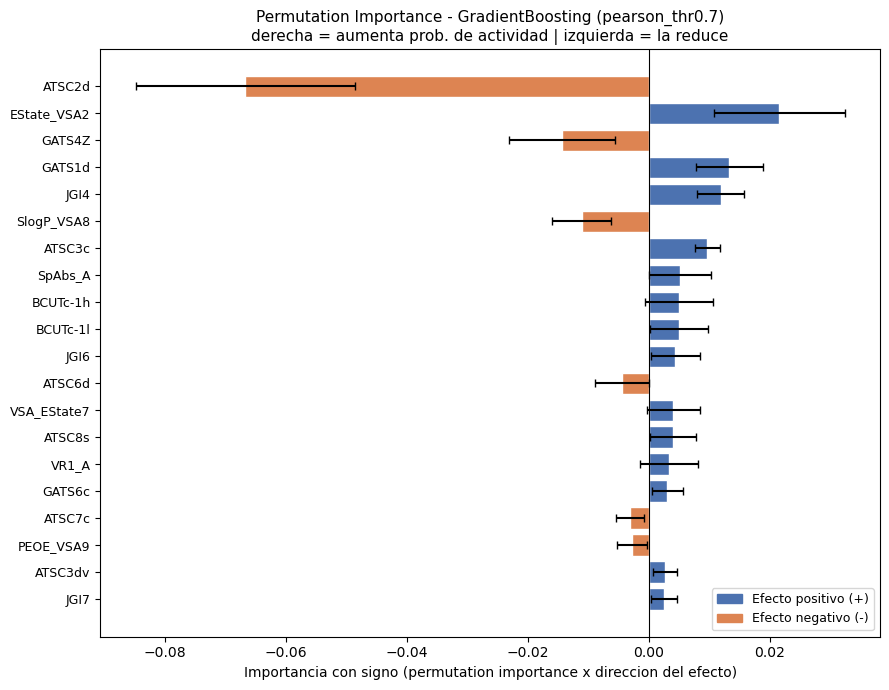

figuras/paso9_permutation_importance_top1_GradientBoosting_mordred.png guardado.

[2/3] Permutation importance: LightGBM | pearson_thr0.7 (149 descriptores)
Top 20 descriptores por importancia (ROC-AUC):
 descriptor  importance_mean  importance_std       effect
     ATSC2d         0.016114        0.006899 negativo (-)
       JGI4         0.013978        0.005336 positivo (+)
     GATS4Z         0.011866        0.009696 negativo (-)
 PEOE_VSA11         0.010924        0.005919 positivo (+)
       JGI7         0.006441        0.004715 positivo (+)
    SpAbs_A         0.006157        0.005051 positivo (+)
     GATS1d         0.005832        0.005500 positivo (+)
VSA_EState7         0.004475        0.003789 positivo (+)
     ATSC8s         0.003411        0.002188 negativo (-)
   BCUTd-1l         0.003281        0.002146 negativo (-)
       JGI6         0.003216        0.004208 positivo (+)
      VR1_A         0.002940        0.002696 positivo (+)
 SlogP_VSA8         0.002688        0.0018

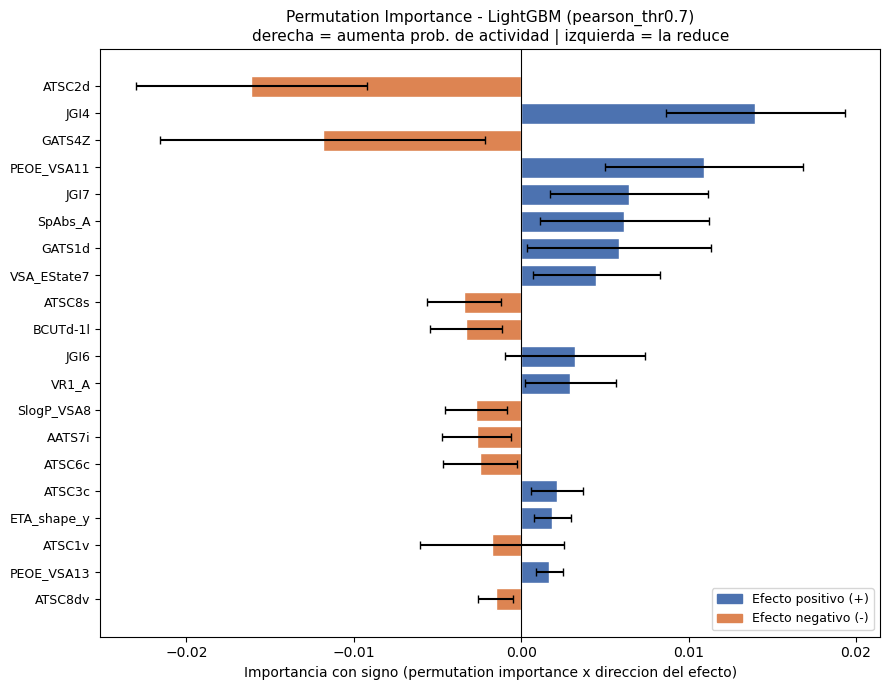

figuras/paso9_permutation_importance_top2_LightGBM_mordred.png guardado.

[3/3] Permutation importance: XGBoost | pearson_thr0.7 (149 descriptores)
Top 20 descriptores por importancia (ROC-AUC):
 descriptor  importance_mean  importance_std       effect
     ATSC2d         0.014929        0.007083 negativo (-)
       JGI4         0.013548        0.011116 positivo (+)
 SlogP_VSA8         0.007562        0.003127 negativo (-)
     ATSC3s         0.007253        0.004003 positivo (+)
     GATS4Z         0.007212        0.012429 negativo (-)
 PEOE_VSA11         0.007164        0.009352 positivo (+)
     ATSC7c         0.006855        0.002075 negativo (-)
     ATSC6c         0.005840        0.004158 positivo (+)
   BCUTc-1l         0.005344        0.002782 positivo (+)
      VR1_A         0.004589        0.005366 positivo (+)
  BCUTdv-1h         0.003354        0.003036 positivo (+)
     ATSC5s         0.002973        0.003560 positivo (+)
     ATSC1v         0.002494        0.004262 negati

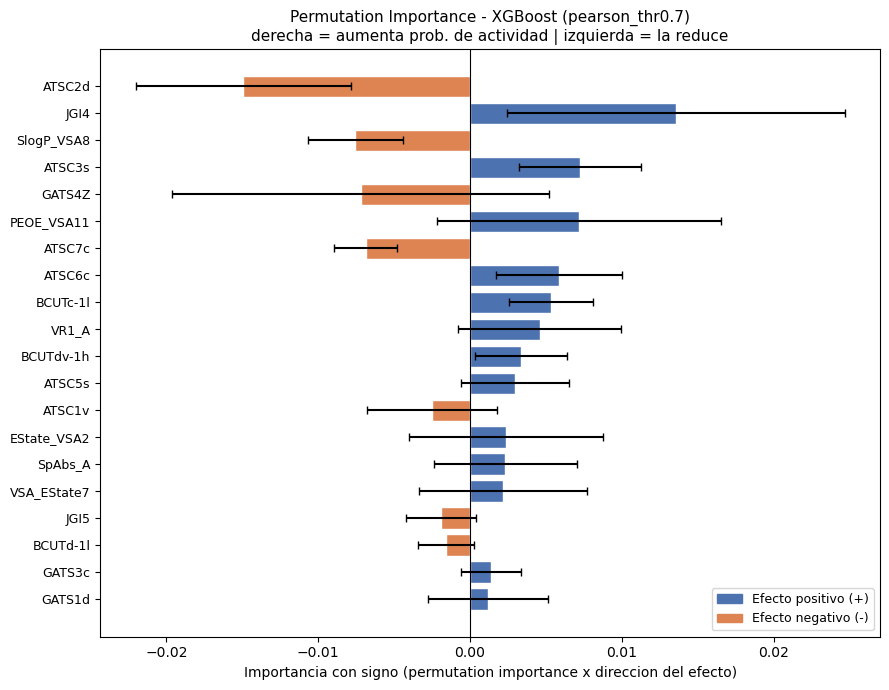

figuras/paso9_permutation_importance_top3_XGBoost_mordred.png guardado.

paraso9_permutation_importance_all.csv guardado con la importancia de los TOP 3 modelos del feature set ganador (pearson_thr0.7).


In [ ]:

# La importancia por permutacion mide cuanto empeora el rendimiento del
# modelo (ROC-AUC) al barajar aleatoriamente los valores de un descriptor,
# rompiendo su relacion con la actividad. Se calcula sobre el TEST SET (no
# sobre train), para que refleje la contribucion real del descriptor a la
# capacidad de generalizacion, no a su ajuste a los datos de entrenamiento.
#
# La importancia por permutacion solo mide MAGNITUD (cuanto importa), no
# DIRECCION (si el descriptor favorece o penaliza la actividad). Para
# estimar la direccion se calcula la correlacion de Pearson entre el valor
# del descriptor y la probabilidad predicha por el propio modelo en el test
# set: correlacion positiva -> el descriptor aumenta la probabilidad de
# actividad; correlacion negativa -> la reduce. Es una aproximacion (no
# capta relaciones no monotonas), pero es el criterio habitual en QSAR
# cuando se usan modelos no lineales que no tienen coeficientes directos.
#
# En el grafico, la barra se dibuja hacia la DERECHA si el descriptor tiene
# efecto positivo sobre la actividad y hacia la IZQUIERDA si tiene efecto
# negativo (importancia con signo = importancia * signo de la correlacion).
#
# Se reutilizan los mismos TOP 3 modelos (top3) y el mismo feature set
# ganador (best_fs_name / fs_cols) ya seleccionados en la seccion anterior.

N_TOP_DESCRIPTORS = 20
N_REPEATS_PI       = 30

def permutation_importance_report(model_name, est, fs_name, feat_cols, X_te, y_te,
                                   n_repeats=N_REPEATS_PI, random_state=42):
    result = permutation_importance(
        est, X_te[feat_cols], y_te,
        scoring="roc_auc",
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=-1,
    )

    if hasattr(est, "predict_proba"):
        y_prob = est.predict_proba(X_te[feat_cols])[:, 1]
    else:
        y_prob = est.decision_function(X_te[feat_cols])

    directions = []
    for col in feat_cols:
        col_vals = X_te[col].values
        if np.std(col_vals) == 0:
            directions.append(0.0)
        else:
            r, _ = pearsonr(col_vals, y_prob)
            directions.append(r)

    imp_df = pd.DataFrame({
        "descriptor"     : feat_cols,
        "importance_mean": result.importances_mean,
        "importance_std" : result.importances_std,
        "direction_corr" : directions,
    })
    imp_df["sign"] = np.where(imp_df["direction_corr"] >= 0, 1, -1)
    imp_df["signed_importance"] = imp_df["importance_mean"] * imp_df["sign"]
    imp_df["effect"] = np.where(imp_df["direction_corr"] >= 0, "positivo (+)", "negativo (-)")
    imp_df = imp_df.reindex(
        imp_df["importance_mean"].sort_values(ascending=False).index
    ).reset_index(drop=True)
    imp_df.insert(0, "model", model_name)
    imp_df.insert(1, "feature_set", fs_name)
    return imp_df


all_importance_dfs = []

for rank, row in top3.iterrows():
    rank += 1
    model_name = row["model"]
    key        = f"{model_name}__{best_fs_name}"
    est        = best_estimators[key]

    print("\n" + "=" * 60)
    print(f"[{rank}/3] Permutation importance: {model_name} | {best_fs_name} ({len(fs_cols)} descriptores)")
    print("=" * 60)

    imp_df = permutation_importance_report(model_name, est, best_fs_name, fs_cols, X_test_full, y_test)
    all_importance_dfs.append(imp_df)

    top_n = imp_df.head(N_TOP_DESCRIPTORS)
    out_csv = f'{OUTPUT_DIR_INT}/paso9_permutation_importance_top{rank}_{model_name}.csv'
    imp_df.to_csv(out_csv, index=False)
    print(f"Top {N_TOP_DESCRIPTORS} descriptores por importancia (ROC-AUC):")
    print(top_n[["descriptor", "importance_mean", "importance_std", "effect"]].to_string(index=False))
    print(f"{out_csv} guardado.")

    # Orden visual: de mayor a menor importancia absoluta, de arriba a abajo
    top_n_plot = top_n.iloc[::-1]
    colors = np.where(top_n_plot["sign"] > 0, "#4C72B0", "#DD8452")

    fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(top_n_plot))))
    y_pos = np.arange(len(top_n_plot))
    ax.barh(y_pos, top_n_plot["signed_importance"],
            xerr=top_n_plot["importance_std"],
            color=colors, edgecolor="white", capsize=3)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_n_plot["descriptor"], fontsize=9)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Importancia con signo (permutation importance x direccion del efecto)")
    ax.set_title(f"Permutation Importance - {model_name} ({best_fs_name})\n"
                 f"derecha = aumenta prob. de actividad | izquierda = la reduce", fontsize=11)
    legend_patches = [
        plt.Rectangle((0, 0), 1, 1, color="#4C72B0", label="Efecto positivo (+)"),
        plt.Rectangle((0, 0), 1, 1, color="#DD8452", label="Efecto negativo (-)"),
    ]
    ax.legend(handles=legend_patches, loc="lower right", fontsize=9)
    plt.tight_layout()
    out_png = f'{FIGURAS}/paso9_permutation_importance_top{rank}_{model_name}_mordred.png'
    plt.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"{out_png} guardado.")

df_importance_all = pd.concat(all_importance_dfs, ignore_index=True)
df_importance_all.to_csv(f'{OUTPUT_DIR_INT}/paso9_permutation_importance_all.csv', index=False)
print(f"\nparaso9_permutation_importance_all.csv guardado con la importancia de los TOP 3 modelos "
      f"del feature set ganador ({best_fs_name}).")
